# CS 437 — Deep Learning
## PA6 Part 2: Federated Learning

---

| Part | Topic | Marks |
|------|-------|-------|
| A | Building the FL Infrastructure from Scratch | 35 |
| B | FedAvg, FedProx, Heterogeneity Audit & Training Diagnostics | 27 |
| C | Real-World FL: Distracted Driver Detection (SFD3) | 15 |
| D | Open Challenge: Fairness-Aware Aggregation | 23 |
| **Total** | | **100** |

---

**Dataset conventions (Parts A & B):**
- Dataset: **CIFAR-10**
- Clients: K = 10
- Fraction used: frac = 0.1 of the full CIFAR-10 training set
- Dirichlet parameter (where applicable): α = 0.5

**Part C** uses the State Farm Distracted Driver Detection (SFD3) dataset.

**Part D** is an open-ended challenge — you must justify every design decision.

---

> ⚠️ You may **not** use any federated learning library (Flower, TFF, PySyft) in Parts A or B. Every abstraction must be your own implementation.


## Global Imports & Configuration
Run this cell first. All subsequent cells assume these names are in scope.

In [1]:
import os, sys, copy, random, time, math, itertools
from collections import defaultdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from PIL import Image
from sklearn.model_selection import train_test_split

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Global CIFAR-10 constants ─────────────────────────────────────────────────
NUM_CLIENTS = 10
FRAC        = 0.1
ALPHA       = 0.5
NUM_CLASSES = 10
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


Device: cuda


---
# Part A — Building the FL Infrastructure from Scratch
**35 marks**

You may **not** use any federated learning library in Parts A or B.

---


## A1 — Federated Data Pipeline `[8 marks]`

Implement a `DatasetPartitioner` class that:

1. Loads **CIFAR-10** and retains only `frac = 0.1` of the training set (randomly sampled, fixed seed).
2. Partitions the retained samples across **K = 10** clients under three regimes:
   - **IID** — shuffle and split equally.
   - **Label-skew non-IID** — Dirichlet(α = 0.5) allocation per class.
   - **Quantity-skew** — client sizes drawn from LogNormal(0, 1), normalised to sum to total.
3. Provides `get_client_loader(k, regime, batch_size)` and `get_test_loader()`.
4. Implements `visualize_distribution(regime)` — a stacked bar chart of per-client class counts.

After implementing the class, run all three regimes and display the distribution plots.


In [2]:
# TODO [A1] — Implement DatasetPartitioner
# Your class must:
#   - Accept: num_clients, frac, alpha, seed
#   - Store retained dataset indices as self.client_indices[regime]
#   - Implement partition_iid(), partition_dirichlet(), partition_quantity_skew()
#   - Implement get_client_loader(k, regime, batch_size) and get_test_loader()
#   - Implement visualize_distribution(regime) with a stacked bar chart

class DatasetPartitioner:
    _MEAN = (0.4914, 0.4822, 0.4465)
    _STD  = (0.2023, 0.1994, 0.2010)

    def __init__(self, num_clients: int = 10, frac: float = 0.1,
                 alpha: float = 0.5, seed: int = 42):
        self.num_clients = num_clients
        self.frac = frac
        self.alpha = alpha
        self.seed = seed
        
        self.transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(self._MEAN, self._STD),
        ])
        self.transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self._MEAN, self._STD),
        ])

        self.full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
        self.test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=self.transform_test)

        n_total = len(self.full_train)
        self.n_retain = int(n_total * self.frac)
        
        indices = list(range(n_total))
        random.seed(self.seed)
        random.shuffle(indices)
        self.retained_indices = indices[:self.n_retain]
        
        self.labels = np.array(self.full_train.targets)[self.retained_indices]
        self.client_indices = {}

    def partition_iid(self) -> 'DatasetPartitioner':
        idxs = copy.deepcopy(self.retained_indices)
        random.seed(self.seed)
        random.shuffle(idxs)
        
        split = np.array_split(idxs, self.num_clients)
        self.client_indices['iid'] = [list(s) for s in split]
        return self

    def partition_dirichlet(self) -> 'DatasetPartitioner':
        np.random.seed(self.seed)
        n_classes = 10
        client_idxs = [[] for _ in range(self.num_clients)]
        
        for c in range(n_classes):
            c_indices = np.where(self.labels == c)[0]
            np.random.shuffle(c_indices)
            
            proportions = np.random.dirichlet([self.alpha] * self.num_clients)
            proportions = (proportions * len(c_indices)).astype(int)
            diff = len(c_indices) - proportions.sum()
            for i in range(diff):
                proportions[i % self.num_clients] += 1
            start = 0
            for k in range(self.num_clients):
                end = start + proportions[k]
                client_idxs[k].extend(np.array(self.retained_indices)[c_indices[start:end]])
                start = end
        self.client_indices['dirichlet'] = client_idxs
        return self

    def partition_quantity_skew(self) -> 'DatasetPartitioner':
        np.random.seed(self.seed)
        sizes = np.random.lognormal(0, 1, self.num_clients)
        sizes = (sizes / sizes.sum() * self.n_retain).astype(int)
        
        diff = self.n_retain - sizes.sum()
        for i in range(diff):
            sizes[i % self.num_clients] += 1
        idxs = copy.deepcopy(self.retained_indices)
        random.seed(self.seed)
        random.shuffle(idxs)
        client_idxs = []
        start = 0
        for s in sizes:
            client_idxs.append(idxs[start:start+s])
            start += s
            
        self.client_indices['quantity'] = client_idxs
        return self

    def get_client_loader(self, k: int, regime: str = 'dirichlet',
                           batch_size: int = 32) -> DataLoader:
        idxs = self.client_indices[regime][k]
        subset = Subset(self.full_train, idxs)
        subset.dataset.transform = self.transform_train
        return DataLoader(subset, batch_size=batch_size, shuffle=True)

    def get_test_loader(self, batch_size: int = 256) -> DataLoader:
        return DataLoader(self.test_set, batch_size=batch_size, shuffle=False)

    def visualize_distribution(self, regime: str = 'dirichlet',
                                figsize=(13, 4)) -> np.ndarray:
        client_idxs = self.client_indices[regime]
        counts = np.zeros((self.num_clients, 10))
        
        all_targets = np.array(self.full_train.targets)
        for k in range(self.num_clients):
            k_labels = all_targets[client_idxs[k]]
            for l in range(10):
                counts[k, l] = np.sum(k_labels == l)
                
        plt.figure(figsize=figsize)
        bottom = np.zeros(self.num_clients)
        for l in range(10):
            plt.bar(range(self.num_clients), counts[:, l], bottom=bottom, label=CIFAR_CLASSES[l])
            bottom += counts[:, l]
        plt.title(f'Data Distribution per Client ({regime.upper()})')
        plt.xlabel('Client ID')
        plt.ylabel('Number of Samples')
        plt.xticks(range(self.num_clients))
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()


100%|██████████| 170M/170M [08:43<00:00, 326kB/s] 


Total retained samples: 5000
  iid         : sizes = [500, 500, 500, 500, 500, 500, 500, 500, 500, 500], min=500, max=500
  dirichlet   : sizes = [532, 299, 384, 698, 584, 359, 356, 649, 418, 721], min=299, max=721
  quantity    : sizes = [412, 219, 480, 1150, 198, 198, 1216, 540, 156, 431], min=156, max=1216


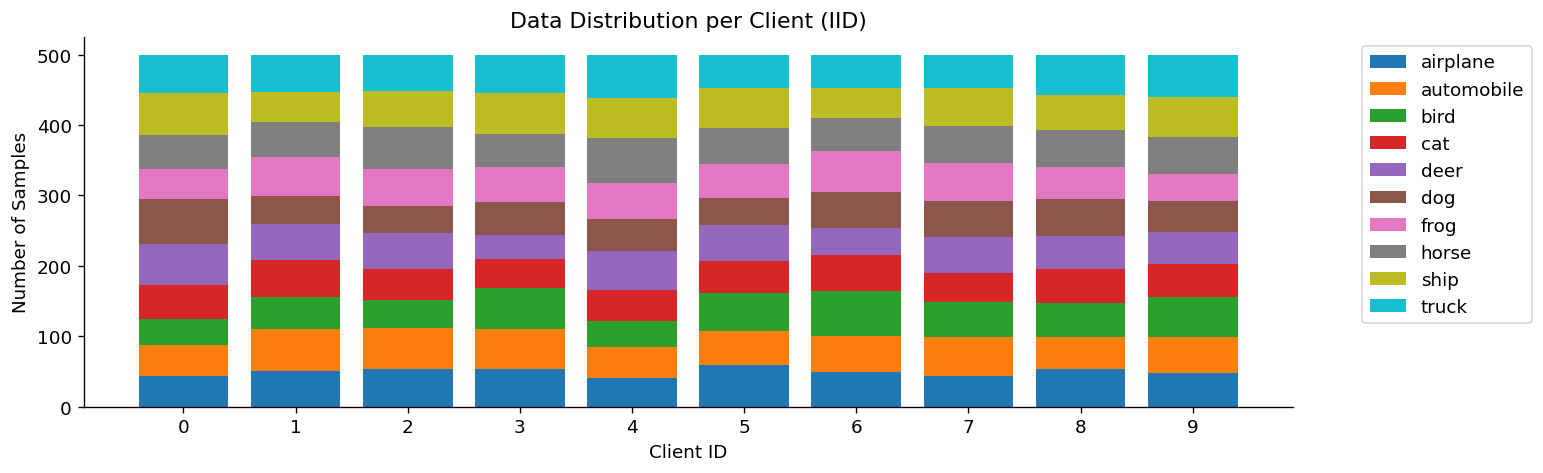

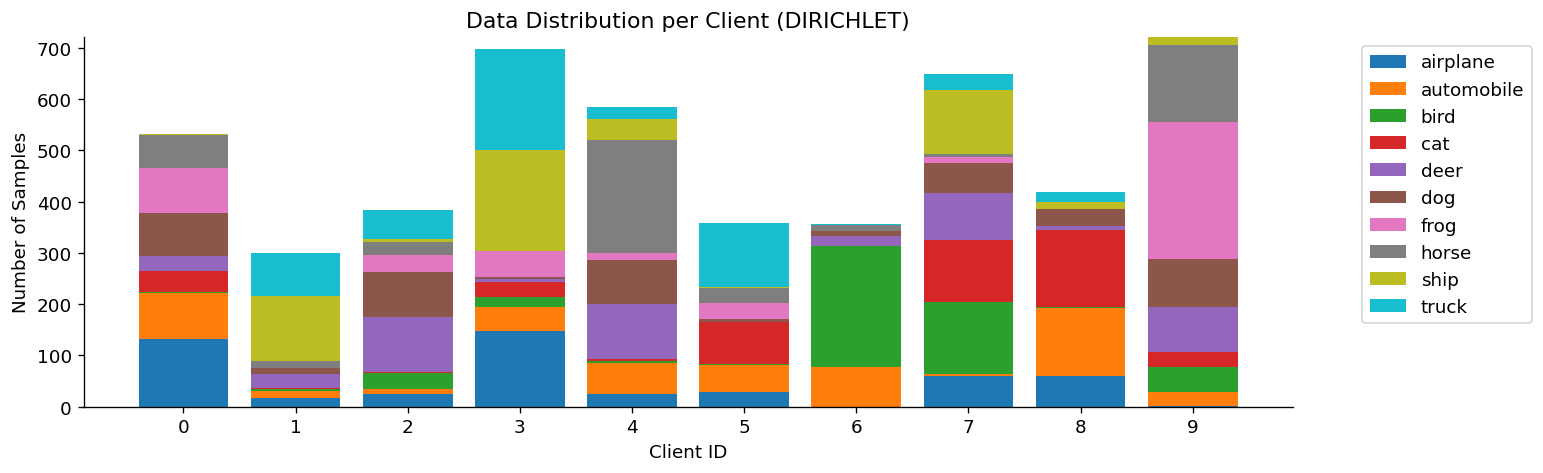

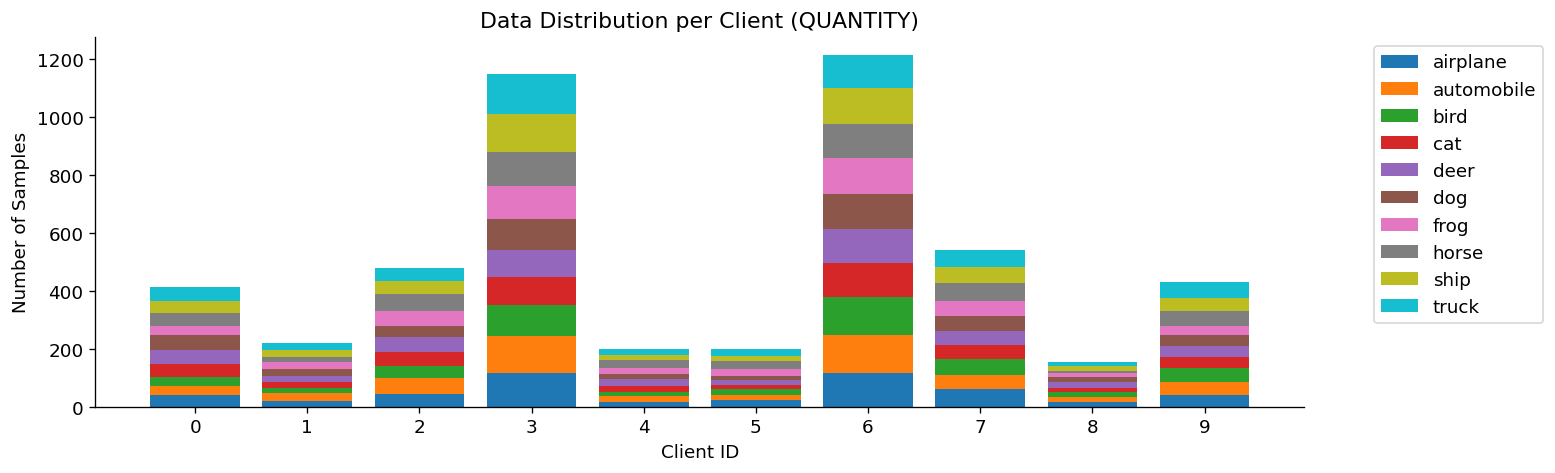

In [3]:
# Run all three regimes and display distribution plots
partitioner = DatasetPartitioner(
    num_clients=NUM_CLIENTS, frac=FRAC, alpha=ALPHA, seed=SEED)
partitioner.partition_iid()
partitioner.partition_dirichlet()
partitioner.partition_quantity_skew()

print(f'Total retained samples: {partitioner.n_retain}')
for regime in ['iid', 'dirichlet', 'quantity']:
    sizes = [len(idx) for idx in partitioner.client_indices[regime]]
    print(f'  {regime:12s}: sizes = {sizes}, '
          f'min={min(sizes)}, max={max(sizes)}')

for regime in ['iid', 'dirichlet', 'quantity']:
    partitioner.visualize_distribution(regime=regime)


**A1 — Observations [write 2–3 sentences per regime]:**

*IID:*

In the IID regime, the data is perfectly balanced across the board. Every client receives exactly 500 samples, and the internal class distribution is uniformly split among all 10 categories. This represents an idealized baseline where no single client has specialized data or a volume advantage.

*Dirichlet (α = 0.5):*

The Dirichlet partition introduces severe label skew, creating highly concentrated and non-uniform class distributions. For example, Client 6's dataset is heavily dominated by the "bird" class, while other clients are completely missing certain categories. The total volume of data also fluctuates moderately between clients (ranging from 299 to 721 samples), mirroring a much more realistic, heterogeneous learning environment.

*Quantity-skew:*

In this regime, the underlying class proportions remain relatively uniform within each client, but the total volume of data varies drastically. Client 6 holds over 1,200 samples, whereas Client 8 has 156. This models a scenario where some edge devices have collected massive amounts of data over time while others have barely been used, creating a severe imbalance in individual client influence.


## A2 — Server–Client Communication Loop `[12 marks]`

Implement `FederatedServer` and `FederatedClient` from scratch — **no FL library permitted**.

Requirements:
- `FederatedClient.receive_model(state_dict)` — loads broadcasted global weights.
- `FederatedClient.local_train(E, lr, mu=0.0)` — runs E local SGD epochs. When `mu > 0`, adds the FedProx proximal term `(μ/2)‖w − w_global‖²` to the local loss. Returns updated `state_dict`.
- `FederatedServer.broadcast(selected)` — sends current global model to selected client indices.
- `FederatedServer.aggregate(updates)` — weighted FedAvg over `(state_dict, n_samples)` pairs.
- `FederatedServer.run_round(t, E, lr, mu, client_frac)` — one complete FL round; logs per-client weight norms, gradient norms, and round payload size in bytes.
- `FederatedServer.evaluate()` — returns global test accuracy.

Use the `SmallCNN` backbone defined below. Verify by running a 2-round smoke test.


In [4]:
# PROVIDED — SmallCNN backbone and helper utilities (do not modify)

class SmallCNN(nn.Module):
    """Lightweight 3-conv-block CNN for CIFAR-10 (~140 K parameters)."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def _weight_norm(model: nn.Module) -> float:
    return sum(p.data.norm(2).item() ** 2
               for p in model.parameters()) ** 0.5

def _grad_norm(model: nn.Module) -> float:
    sq = sum(p.grad.norm(2).item() ** 2
             for p in model.parameters() if p.grad is not None)
    return sq ** 0.5

def _param_bytes(model: nn.Module) -> int:
    return sum(p.numel() * 4 for p in model.parameters())


In [5]:
# TODO [A2a] — Implement FederatedClient

class FederatedClient:
    def __init__(self, client_id: int, loader: DataLoader,
                 num_samples: int):
        self.client_id = client_id
        self.loader = loader
        self.num_samples = num_samples
        self.model = None
        self.last_grad_norm = 0.0

    def receive_model(self, global_sd: dict):
        """Load a deep copy of the broadcasted global state dict."""
        self.model = SmallCNN(NUM_CLASSES).to(DEVICE)
        self.model.load_state_dict(copy.deepcopy(global_sd))

    def local_train(self, E: int, lr: float, mu: float = 0.0) -> dict:
        """
        Run E epochs of SGD on local data.
        When mu > 0, add FedProx proximal term: (mu/2) * ||w - w_global||^2
        Store mean gradient norm in self.last_grad_norm.
        Return a deep copy of the updated state dict.
        """
        self.model.train()
        global_weights = [p.clone().detach() for p in self.model.parameters()]
        optimizer = optim.SGD(self.model.parameters(), lr=lr)
        
        grad_norms = []
        for epoch in range(E):
            for x, y in self.loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                output = self.model(x)
                loss = F.cross_entropy(output, y)
                if mu > 0:
                    prox_term = 0.0
                    for p, pg in zip(self.model.parameters(), global_weights):
                        prox_term += (p - pg).norm(2) ** 2
                    loss += (mu / 2.0) * prox_term
                loss.backward()
                grad_norms.append(_grad_norm(self.model))
                optimizer.step()
                
        self.last_grad_norm = np.mean(grad_norms) if grad_norms else 0.0
        return copy.deepcopy(self.model.state_dict())


In [6]:
# TODO [A2b] — Implement FederatedServer

class FederatedServer:
    def __init__(self, model: nn.Module,
                 clients: List[FederatedClient],
                 test_loader: DataLoader):
        self.global_model = model.to(DEVICE)
        self.clients = clients
        self.test_loader = test_loader
        self.history = defaultdict(list)

    def broadcast(self, selected: List[int]):
        """Send current global model state dict to selected clients."""
        sd = self.global_model.state_dict()
        for idx in selected:
            self.clients[idx].receive_model(sd)

    def aggregate(self, updates: List[Tuple[dict, int]]):
        """
        Weighted FedAvg aggregation.
        updates: list of (state_dict, n_samples) pairs.
        """
        total_n = sum(n for _, n in updates)
        new_sd = copy.deepcopy(updates[0][0])
        
        for key in new_sd.keys():
            temp = torch.zeros_like(new_sd[key], dtype=torch.float32)
            for sd, n in updates:
                temp += sd[key].to(torch.float32) * (n / total_n)
            new_sd[key] = temp.to(new_sd[key].dtype)
        
        self.global_model.load_state_dict(new_sd)

    def run_round(self, t: int, E: int, lr: float,
                  mu: float = 0.0, client_frac: float = 1.0) -> float:
        """
        One FL round: broadcast -> local_train -> aggregate -> evaluate.
        Log per-client weight norms, gradient norms, payload bytes.
        Return global test accuracy.
        """
        n_sel = max(1, int(client_frac * len(self.clients)))
        selected_indices = random.sample(range(len(self.clients)), n_sel)
        
        self.broadcast(selected_indices)
        
        updates = []
        weight_norms = []
        grad_norms = []
        for idx in selected_indices:
            client = self.clients[idx]
            sd = client.local_train(E, lr, mu)
            updates.append((sd, client.num_samples))
            
            weight_norms.append(_weight_norm(client.model))
            grad_norms.append(client.last_grad_norm)
            
        self.aggregate(updates)
        acc = self.evaluate()
        model_size = _param_bytes(self.global_model)
        total_payload = model_size * 2 * n_sel
        
        self.history['test_acc'].append(acc)
        self.history['weight_norms'].append(weight_norms)
        self.history['grad_norms'].append(grad_norms)
        self.history['payload_bytes'].append(total_payload)
        return acc

    def evaluate(self) -> float:
        """Return global test accuracy on the test set."""
        self.global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = self.global_model(x)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        return correct / total


In [7]:
# PROVIDED — Factory helper (do not modify)
def build_system(partitioner: DatasetPartitioner,
                 regime: str = 'dirichlet',
                 batch_size: int = 32) -> FederatedServer:
    """Wire up server + 10 clients from a given partition regime."""
    test_loader = partitioner.get_test_loader()
    clients = [
        FederatedClient(
            client_id=k,
            loader=partitioner.get_client_loader(k, regime=regime, batch_size=batch_size),
            num_samples=len(partitioner.client_indices[regime][k])
        )
        for k in range(partitioner.num_clients)
    ]
    return FederatedServer(SmallCNN(NUM_CLASSES), clients, test_loader)

# 2-round smoke test — must print two round accuracies and payload info
smoke = build_system(partitioner, 'dirichlet')
for t in range(2):
    acc = smoke.run_round(t, E=1, lr=0.01)
    print(f'Round {t}: acc={acc:.4f}')

payload_mb = smoke.history['payload_bytes'][0] / 1e6
print(f'Payload per round: {payload_mb:.2f} MB  ({smoke.history["payload_bytes"][0]:,} bytes)')
print('A2 smoke test passed.')


Round 0: acc=0.1371
Round 1: acc=0.1893
Payload per round: 15.13 MB  (15,130,400 bytes)
A2 smoke test passed.


## A3 — Gradient-Averaging Equivalence Verification `[8 marks]`

Proposition 3.1 from the lecture states:

> With E = 1 local step and equal client weights, one round of FedAvg is **exactly equivalent** to one step of gradient descent on the global objective F(w).

**Tasks:**
1. Implement a 1-D quadratic federated system with K = 5 clients, each having `F_k(w) = (a_k/2)(w − w_k*)²`.
2. Numerically verify that `|w_FedAvg(t) − w_cent(t)| < 1e-10` for all t when E = 1.
3. Plot Δ(t) = `|w_FedAvg(t) − w_cent(t)|` on a log-scale for E ∈ {1, 2, 5, 10} over T = 50 rounds.
4. On a separate subplot, plot `|w(t) − w*|` for all methods.


In [8]:
# TODO [A3] — 1-D Quadratic Federated System

np.random.seed(0)
K_SYN   = 5
# Generate curvatures and local minimisers
a_k     = np.random.uniform(0.5, 4.0, K_SYN)
wk_star = np.random.uniform(-5.0, 5.0, K_SYN)
p_k     = np.ones(K_SYN) / K_SYN

# TODO: Compute the global minimiser w* of F(w) = sum_k p_k * (a_k/2)(w - wk*)^2
w_star = np.sum(p_k * a_k * wk_star) / np.sum(p_k * a_k)  # replace with analytic expression
#raise NotImplementedError

def grad_Fk(w, k):
    return a_k[k] * (w - wk_star[k])

def grad_F(w):
    return np.sum([p_k[k] * grad_Fk(w, k) for k in range(K_SYN)])

def fedavg_1d(w0, eta, E, T):
    w_global = w0
    history = [w_global]
    for _ in range(T):
        local_ws = []
        for k in range(K_SYN):
            w_k = w_global
            for _ in range(E):
                w_k = w_k - eta * grad_Fk(w_k, k)
            local_ws.append(w_k)
        w_global = np.sum([p_k[k] * local_ws[k] for k in range(K_SYN)])
        history.append(w_global)
    return np.array(history)

def cent_gd_1d(w0, eta, T):
    """Run T steps of centralised gradient descent."""
    w = w0
    history = [w]
    for _ in range(T):
        w = w - eta * grad_F(w)
        history.append(w)
    return np.array(history)

W0, ETA, T_SYN = 0.0, 0.05, 50

traj_cent = cent_gd_1d(W0, ETA, T_SYN)
traj_e1   = fedavg_1d(W0, ETA, E=1, T=T_SYN)

max_err = np.max(np.abs(traj_e1 - traj_cent))
print(f'Max |w_FedAvg(E=1) - w_cent| over {T_SYN} rounds: {max_err:.2e}')
assert max_err < 1e-10, 'Equivalence check FAILED — revisit your implementation!'
print('>>> Proposition 3.1 verified: E=1 FedAvg is numerically identical to centralised GD.')


Max |w_FedAvg(E=1) - w_cent| over 50 rounds: 1.33e-15
>>> Proposition 3.1 verified: E=1 FedAvg is numerically identical to centralised GD.


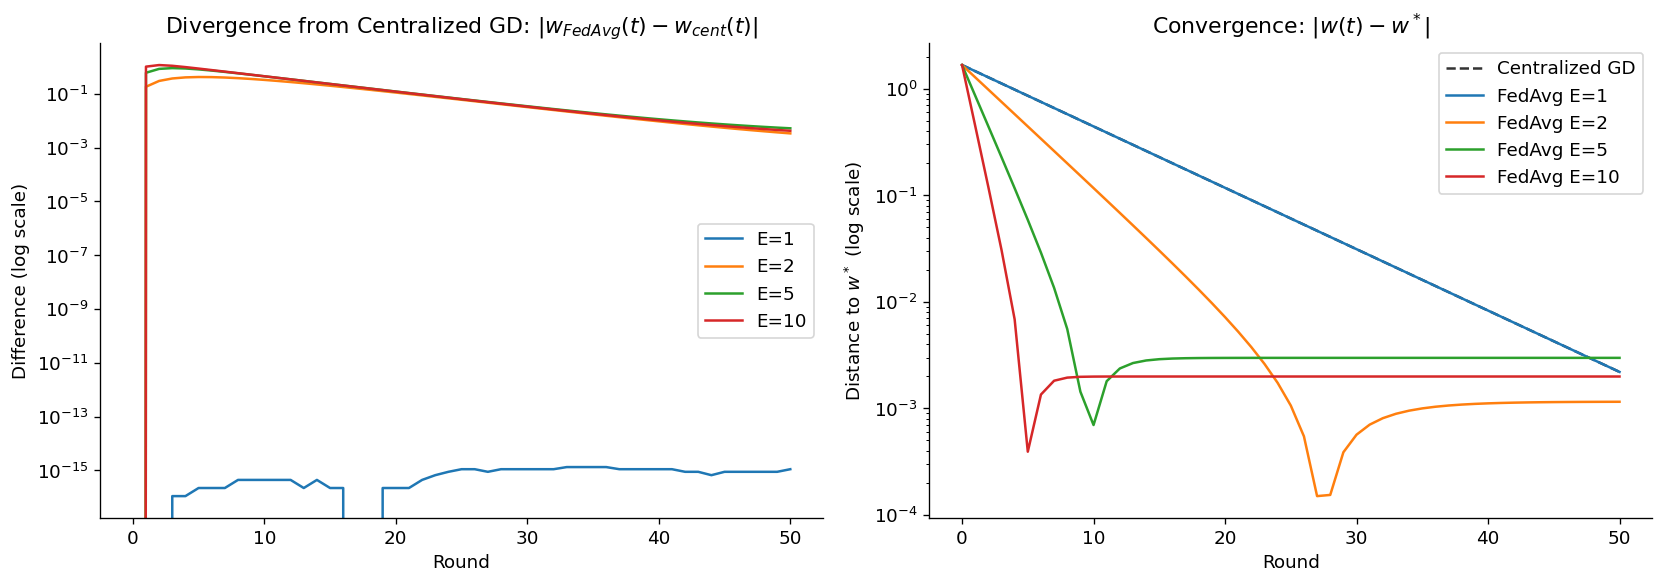

In [9]:
# TODO [A3 continued] — Produce the two-panel divergence plot
E_list = [1, 2, 5, 10]
trajectories = {e: fedavg_1d(W0, ETA, e, T_SYN) for e in E_list}

plt.figure(figsize=(14, 5))
# Panel 1: log-scale plot of |w_FedAvg - w_cent| for E in {1, 2, 5, 10}
plt.subplot(1, 2, 1)
for e in E_list:
    diff = np.abs(trajectories[e] - traj_cent)
    plt.plot(diff, label=f'E={e}')
plt.yscale('log')
plt.title('Divergence from Centralized GD: $|w_{FedAvg}(t) - w_{cent}(t)|$')
plt.xlabel('Round')
plt.ylabel('Difference (log scale)')
plt.legend()
# Panel 2: log-scale plot of |w(t) - w*| for centralised and all FedAvg variants
plt.subplot(1, 2, 2)
plt.plot(np.abs(traj_cent - w_star), 'k--', label='Centralized GD', alpha=0.8)
for e in E_list:
    plt.plot(np.abs(trajectories[e] - w_star), label=f'FedAvg E={e}')
plt.yscale('log')
plt.title('Convergence: $|w(t) - w^*|$')
plt.xlabel('Round')
plt.ylabel('Distance to $w^*$ (log scale)')
plt.legend()

plt.tight_layout()
plt.show()


**A3 — Discussion [3–4 sentences: what happens to convergence as E grows?]:**

*Your answer here.*

As the number of local epochs (E) grows, the model initially drops toward the global minimum much faster since it takes more gradient steps per communication round. However, higher values of $E$ ultimately cause the model's error to plateau at a higher floor, with E=10 flattening out quickly around 2 x 10^-3. This plateau happens because taking too many consecutive local steps pulls the client models toward their own specific local minimizers, causing them to drift away from the true global objective. Because of this severe client drift, only E=1 perfectly tracks the centralized gradient descent path and continues to converge without hitting an error floor.

## A4 — Instrumentation Dashboard `[7 marks]`

Using the infrastructure from A2, run **30 rounds** of FedAvg on the Dirichlet partition (E = 5, lr = 0.01). After training, produce a single **4-panel instrumentation dashboard** showing:

1. **Global test accuracy** vs round.
2. **Mean per-client weight norm** vs round (with ±1 std shading across clients).
3. **Mean per-client gradient norm** vs round (with ±1 std shading).
4. **Cumulative payload bytes transferred** vs round — annotate the total cost in MB.


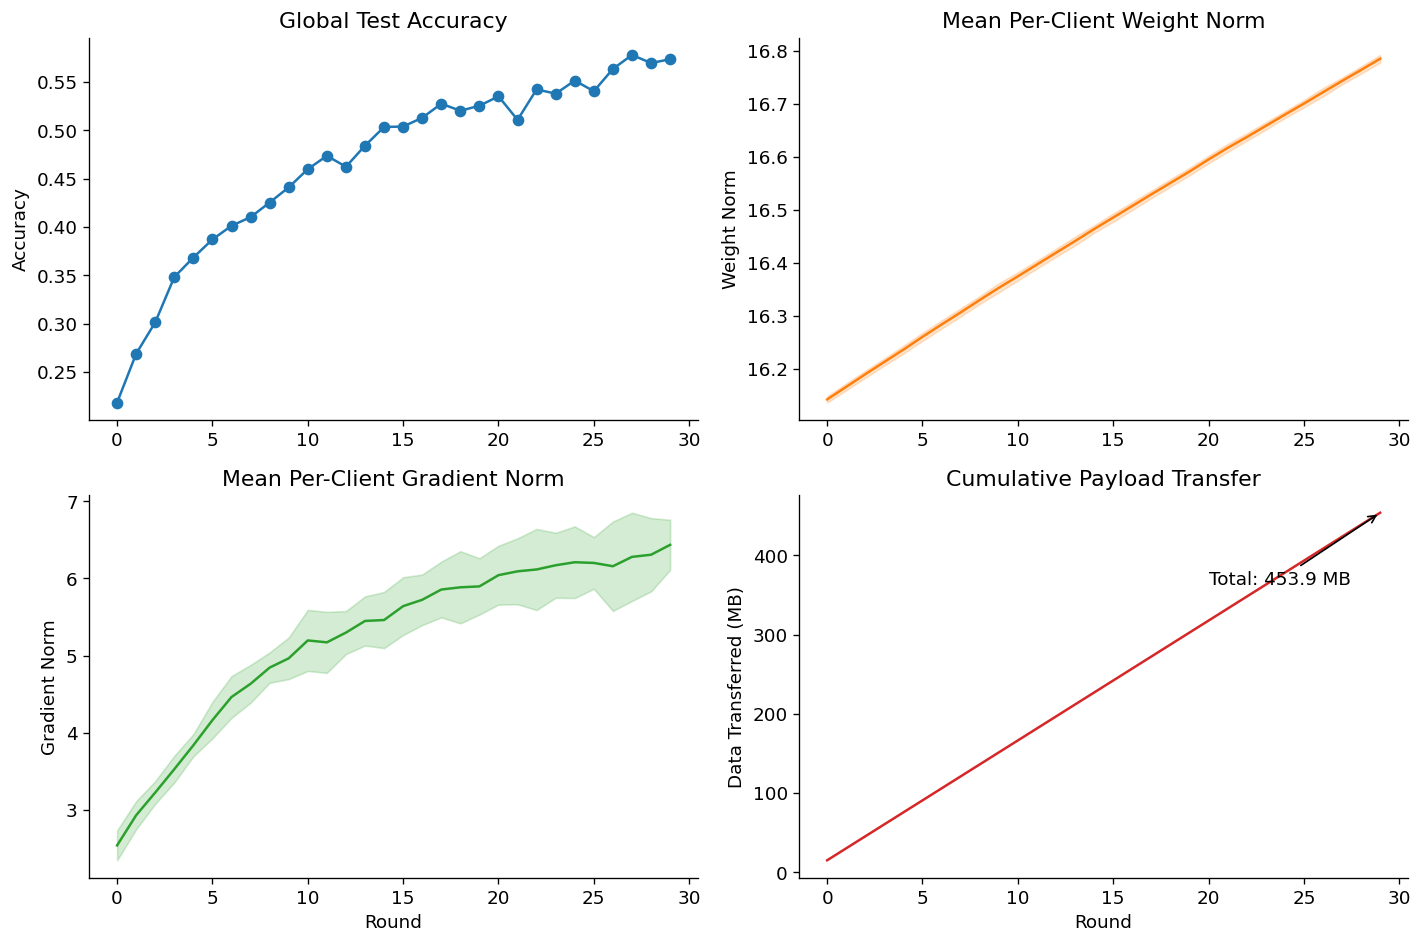

In [10]:
# TODO [A4] — Run 30 rounds and produce the 4-panel dashboard

T_A4 = 30
server_a4 = build_system(partitioner, 'dirichlet', batch_size=32)

# TODO: run T_A4 rounds with E=5, lr=0.01
for t in range(T_A4):
    server_a4.run_round(t, E=5, lr=0.01)

# TODO: extract history and build 4-panel figure
# hist = server_a4.history
# Panels: accuracy, weight norms (±std), gradient norms (±std), cumulative payload
hist = server_a4.history

accs = hist['test_acc']
wn_raw = hist['weight_norms']
gn_raw = hist['grad_norms']
payloads = np.cumsum(hist['payload_bytes']) / 1e6

wn_mean = np.mean(wn_raw, axis=1) if np.ndim(wn_raw) > 1 else np.array(wn_raw)
wn_std = np.std(wn_raw, axis=1) if np.ndim(wn_raw) > 1 else np.zeros(T_A4)
gn_mean = np.mean(gn_raw, axis=1) if np.ndim(gn_raw) > 1 else np.array(gn_raw)
gn_std = np.std(gn_raw, axis=1) if np.ndim(gn_raw) > 1 else np.zeros(T_A4)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(range(T_A4), accs, marker='o', color='C0')
axs[0, 0].set_title('Global Test Accuracy')
axs[0, 0].set_ylabel('Accuracy')

axs[0, 1].plot(range(T_A4), wn_mean, color='C1')
axs[0, 1].fill_between(range(T_A4), wn_mean - wn_std, wn_mean + wn_std, color='C1', alpha=0.2)
axs[0, 1].set_title('Mean Per-Client Weight Norm')
axs[0, 1].set_ylabel('Weight Norm')

axs[1, 0].plot(range(T_A4), gn_mean, color='C2')
axs[1, 0].fill_between(range(T_A4), gn_mean - gn_std, gn_mean + gn_std, color='C2', alpha=0.2)
axs[1, 0].set_title('Mean Per-Client Gradient Norm')
axs[1, 0].set_xlabel('Round')
axs[1, 0].set_ylabel('Gradient Norm')

axs[1, 1].plot(range(T_A4), payloads, color='C3')
axs[1, 1].set_title('Cumulative Payload Transfer')
axs[1, 1].set_xlabel('Round')
axs[1, 1].set_ylabel('Data Transferred (MB)')
axs[1, 1].annotate(f'Total: {payloads[-1]:.1f} MB', xy=(T_A4-1, payloads[-1]), 
                   xytext=(T_A4-10, payloads[-1] * 0.8),
                   arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.tight_layout()
plt.show()


**A4 — Gradient norm interpretation [answer: when does it peak and why?]:**

*Your answer here.*

Based on the graph, the gradient norm peaks at the very end of training (round 30). Instead of shrinking as the model converges, the gradients keep growing because the clients have highly skewed local data. As the global model learns a general "consensus" representation, it becomes a worse fit for any individual client's specialized dataset. By the final rounds, the tension between the global model and the local data is at its highest, resulting in the clients computing much larger gradients as they try to aggressively pull the weights back toward their own local minima.


---
# Part B — FedAvg, FedProx, Heterogeneity Audit & Training Diagnostics
**27 marks**

---


## B1 — FedProx Implementation and μ Sweep `[8 marks]`

FedProx is already embedded in `FederatedClient.local_train(mu=...)`. Run a sweep over **μ ∈ {0, 0.01, 0.1, 1, 10}** on the Dirichlet non-IID partition with **E = 10** over **T = 30 rounds**.

Produce three plots:
1. Convergence curves (one line per μ).
2. Final test accuracy vs μ (bar chart).
3. Rounds to reach 40% accuracy vs μ — annotate the "sweet-spot" μ.

Also compute and print the **bias** at μ → 0 and the **frozen** outcome at μ → ∞ using the synthetic 1-D system from A3.


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57/320569527.py:22: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(range(T_B1), accs, label=f'$\mu$={mu}')
/tmp/ipykernel_57/320569527.py:30: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('Final Test Accuracy vs $\mu$')
/tmp/ipykernel_57/320569527.py:31: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel('$\mu$')
/tmp/ipykernel_57/320569527.py:42: SyntaxWarning: invalid escape sequence '\m'
  axs[2].set_xlabel('$\mu$')
/tmp/ipyker

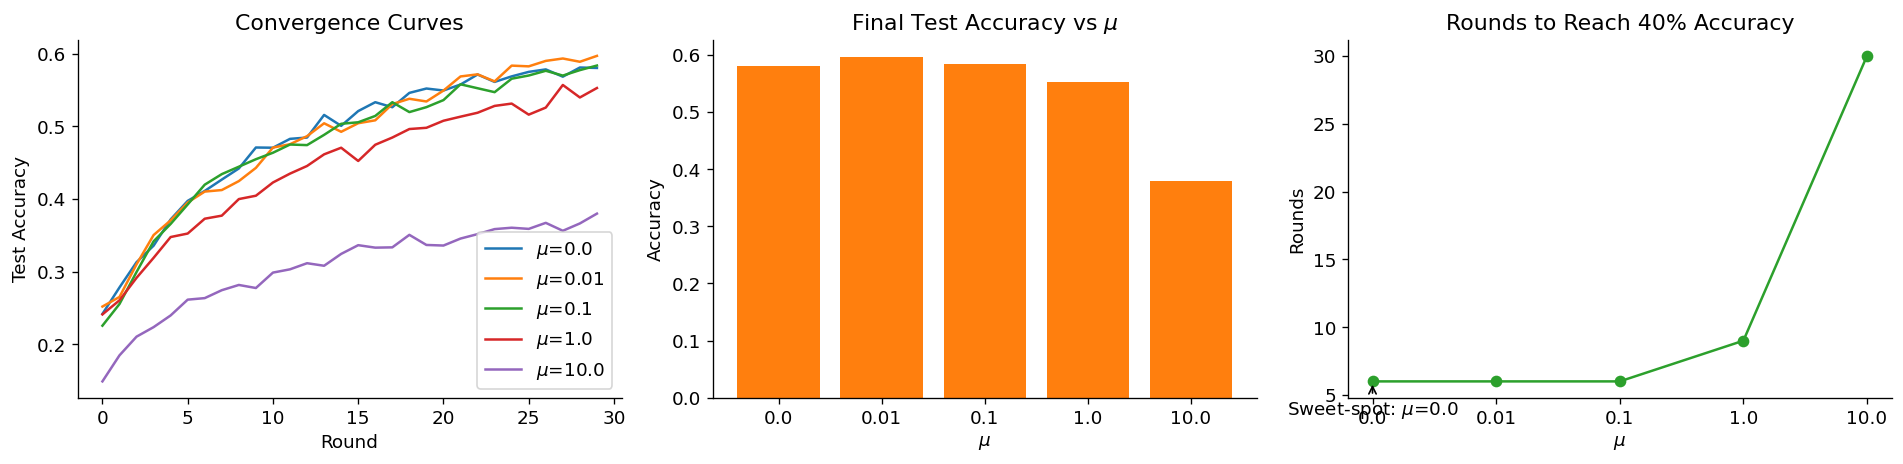

In [11]:
# TODO [B1] — μ sweep and three-panel plot

MU_LIST = [0.0, 0.01, 0.1, 1.0, 10.0]
E_PROX  = 5
T_B1    = 30
THRESH  = 0.40

# TODO: run FedProx for each mu and collect accuracy curves
# TODO: produce the three plots
results = {}
for mu in MU_LIST:
    server = build_system(partitioner, 'dirichlet', batch_size=32)
    accs = []
    for t in range(T_B1):
        acc = server.run_round(t, E=E_PROX, lr=0.01, mu=mu)
        accs.append(acc)
    results[mu] = accs

fig, axs = plt.subplots(1, 3, figsize=(16, 4))

for mu, accs in results.items():
    axs[0].plot(range(T_B1), accs, label=f'$\mu$={mu}')
axs[0].set_title('Convergence Curves')
axs[0].set_xlabel('Round')
axs[0].set_ylabel('Test Accuracy')
axs[0].legend()

final_accs = [results[mu][-1] for mu in MU_LIST]
axs[1].bar([str(m) for m in MU_LIST], final_accs, color='C1')
axs[1].set_title('Final Test Accuracy vs $\mu$')
axs[1].set_xlabel('$\mu$')
axs[1].set_ylabel('Accuracy')

rounds_to_thresh = []
for mu in MU_LIST:
    acc_arr = np.array(results[mu])
    idx = np.where(acc_arr >= THRESH)[0]
    rounds_to_thresh.append(idx[0] if len(idx) > 0 else T_B1)

axs[2].plot([str(m) for m in MU_LIST], rounds_to_thresh, marker='o', color='C2')
axs[2].set_title('Rounds to Reach 40% Accuracy')
axs[2].set_xlabel('$\mu$')
axs[2].set_ylabel('Rounds')

best_mu_idx = np.argmin(rounds_to_thresh)
best_mu = MU_LIST[best_mu_idx]
axs[2].annotate(f'Sweet-spot: $\mu$={best_mu}', 
                xy=(best_mu_idx, rounds_to_thresh[best_mu_idx]), 
                xytext=(0, -20), textcoords='offset points', 
                ha='center', arrowprops=dict(arrowstyle="->", color='black'))

plt.tight_layout()
plt.show()


In [12]:
# TODO [B1 continued] — Bias analysis using the 1-D system from A3
# Compute: aggregate at mu->0 (weighted avg of local minimisers)
# and at mu->inf (frozen at global initialisation)
# Print both values and compare to the true global minimiser w*

mu_0_agg = np.sum(p_k * wk_star)
mu_inf_agg = W0

print(f"Aggregate at mu -> 0 (weighted avg of local minimisers): {mu_0_agg:.4f}")
print(f"Aggregate at mu -> inf (frozen at global init): {mu_inf_agg:.4f}")
print(f"True global minimiser w*: {w_star:.4f}")
print(f"Bias at mu -> 0: {abs(mu_0_agg - w_star):.4f}")
print(f"Bias at mu -> inf: {abs(mu_inf_agg - w_star):.4f}")


Aggregate at mu -> 0 (weighted avg of local minimisers): 1.6447
Aggregate at mu -> inf (frozen at global init): 0.0000
True global minimiser w*: 1.6687
Bias at mu -> 0: 0.0240
Bias at mu -> inf: 1.6687


**B1 — Bias–drift tradeoff [3–4 sentences: why is neither extreme desirable?]:**

*Your answer here.*

Neither extreme is desirable because both prevent the model from finding the true global optimum. As shown in the 1-D synthetic system, setting $\mu \to 0$ provides no regularization, allowing clients to drift toward their own local minima and resulting in a small but permanent bias (0.0240) away from the true global minimizer. Conversely, pushing $\mu \to \infty$ is far worse because it effectively freezes the weights at global initialization (creating a massive bias of 1.6687); you can see this exact failure in the plots, where $\mu=10.0$ cripples learning and takes 30 rounds just to reach 40% accuracy. The ideal approach uses a moderate value (like $\mu=0.01$ or $0.1$) to reign in client drift without suffocating the model's ability to learn.

## B2 — Client Drift Anatomy `[9 marks]`

For the **Dirichlet non-IID partition** with **E = 5**, over **T = 20 rounds**:

1. Plot ‖w_k(t) − w(t)‖ per client per round for both FedAvg (μ = 0) and FedProx (μ = 0.1). Show the cross-client mean as a bold dashed line on each plot.
2. Produce a **cosine similarity heatmap** (clients × rounds) for both algorithms — use a diverging colormap (green = aligned, red = opposing).
3. Report the empirical gradient divergence ∑_k p_k ‖∇F_k(w) − ∇F(w)‖² at each diagnostic round for both algorithms on a shared axis.


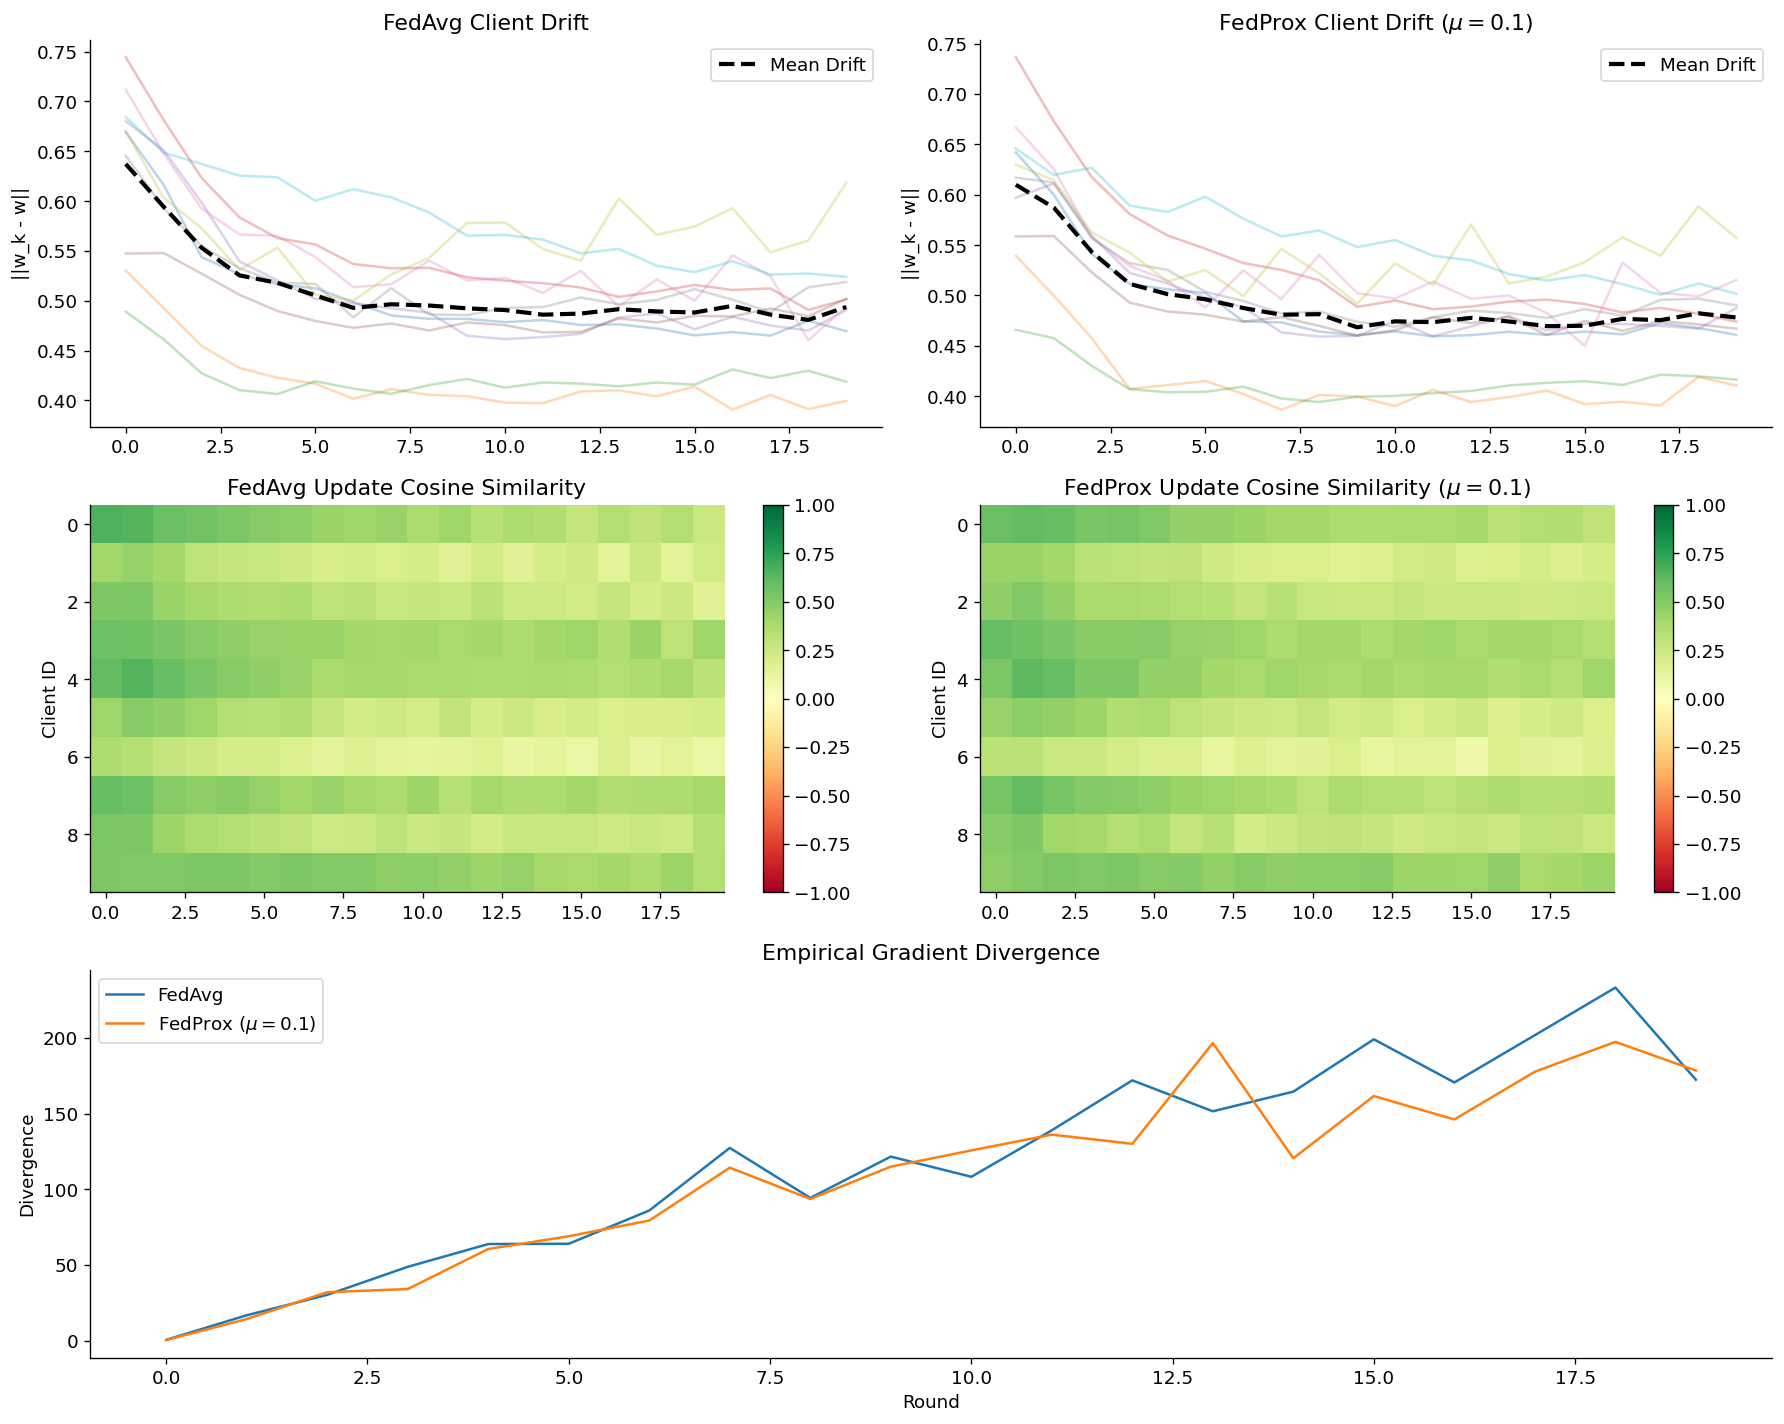

In [13]:
# TODO [B2] — Client drift analysis

def flatten_sd(sd: dict) -> torch.Tensor:
    """Flatten all values of a state dict into a single 1-D tensor."""
    return torch.cat([v.flatten().float() for k, v in sd.items() if 'weight' in k or 'bias' in k])

def run_drift(partitioner, regime, E, T, lr, mu=0.0):
    """
    Run T rounds and at each round record:
      - drift[t, k] = ||w_k(t) - w(t)||  (post-local-train vs global)
      - cos[t, k]   = cosine similarity of client update w.r.t. mean update
    Also compute gradient divergence at each round.
    Return (drift array, cos array, grad_div list).
    """
    server = build_system(partitioner, regime, batch_size=32)
    K = len(server.clients)
    drift_array = np.zeros((T, K))
    cos_array = np.zeros((T, K))
    gdiv_list = []

    for t in range(T):
        global_sd_flat = flatten_sd(server.global_model.state_dict())
        
        grad_k_list = []
        total_samples = 0
        server.global_model.eval()
        for client in server.clients:
            server.global_model.zero_grad()
            for x, y in client.loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = server.global_model(x)
                loss = F.cross_entropy(out, y)
                loss.backward()
                break 
            grad_flat = torch.cat([p.grad.flatten() for p in server.global_model.parameters() if p.grad is not None])
            grad_k_list.append(grad_flat)
            total_samples += client.num_samples
            
        p_k_list = [c.num_samples / total_samples for c in server.clients]
        mean_grad = sum(p * g for p, g in zip(p_k_list, grad_k_list))
        gdiv = sum(p * torch.norm(g - mean_grad)**2 for p, g in zip(p_k_list, grad_k_list)).item()
        gdiv_list.append(gdiv)
        server.broadcast(list(range(K)))
        updates = []
        client_updates_flat = []
        for k, client in enumerate(server.clients):
            sd = client.local_train(E, lr, mu)
            updates.append((sd, client.num_samples))
            local_sd_flat = flatten_sd(sd)
            
            drift_array[t, k] = torch.norm(local_sd_flat - global_sd_flat).item()
            client_updates_flat.append(local_sd_flat - global_sd_flat)
        mean_update = sum(p * u for p, u in zip(p_k_list, client_updates_flat))
        mean_update_norm = torch.norm(mean_update)
        
        for k in range(K):
            u_k = client_updates_flat[k]
            u_k_norm = torch.norm(u_k)
            if mean_update_norm > 0 and u_k_norm > 0:
                cos_array[t, k] = torch.dot(u_k, mean_update) / (u_k_norm * mean_update_norm)
            else:
                cos_array[t, k] = 0.0

        server.aggregate(updates)
        
    return drift_array, cos_array, gdiv_list
T_B2 = 20
drift_avg, cos_avg, gdiv_avg   = run_drift(partitioner, 'dirichlet', E=5, T=T_B2, lr=0.01, mu=0.0)
drift_prx, cos_prx, gdiv_prx   = run_drift(partitioner, 'dirichlet', E=5, T=T_B2, lr=0.01, mu=0.1)

fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])

ax_d1 = fig.add_subplot(gs[0, 0])
ax_d1.plot(drift_avg, alpha=0.3)
ax_d1.plot(drift_avg.mean(axis=1), 'k--', lw=2.5, label='Mean Drift')
ax_d1.set_title('FedAvg Client Drift')
ax_d1.set_ylabel('||w_k - w||')
ax_d1.legend()

ax_d2 = fig.add_subplot(gs[0, 1])
ax_d2.plot(drift_prx, alpha=0.3)
ax_d2.plot(drift_prx.mean(axis=1), 'k--', lw=2.5, label='Mean Drift')
ax_d2.set_title(r'FedProx Client Drift ($\mu=0.1$)')
ax_d2.set_ylabel('||w_k - w||')
ax_d2.legend()

ax_c1 = fig.add_subplot(gs[1, 0])
im1 = ax_c1.imshow(cos_avg.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax_c1.set_title('FedAvg Update Cosine Similarity')
ax_c1.set_ylabel('Client ID')
fig.colorbar(im1, ax=ax_c1)

ax_c2 = fig.add_subplot(gs[1, 1])
im2 = ax_c2.imshow(cos_prx.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax_c2.set_title(r'FedProx Update Cosine Similarity ($\mu=0.1$)')
ax_c2.set_ylabel('Client ID')
fig.colorbar(im2, ax=ax_c2)

ax_g = fig.add_subplot(gs[2, :])
ax_g.plot(gdiv_avg, label='FedAvg')
ax_g.plot(gdiv_prx, label=r'FedProx ($\mu=0.1$)')
ax_g.set_title('Empirical Gradient Divergence')
ax_g.set_xlabel('Round')
ax_g.set_ylabel('Divergence')
ax_g.legend()

plt.tight_layout()
plt.show()

**B2 — Interpretation [150 words: compare drift and gradient alignment under FedAvg vs FedProx]:**

*Your answer here.*

Based on the plots, FedProx ($\mu=0.1$) successfully reduces client drift. In the top panels, the mean drift for FedAvg stablizes near 0.49, while FedProx pulls it slightly lower to around 0.47.The cosine similarity heatmaps reveal that for both algorithms, client updates are well aligned initially (darker green) but slowly lose alignment (fading to pale green/yellow) as the global model converges and clients overfit their highly skewed local data. Because these two heatmaps look nearly identical, it indicates the $\mu=0.1$ mostly restricts the scale of the updates rather than fundamentally altering their direction. Finally, the empirical gradient divergence rises steadily for both methods as training progresses. However, FedProx restrains this divergence in the later rounds, capping it just under 200, whereas FedAvg spikes over 220. This confirms that the proximal penalty successfully prevents the clients' local objectives from drifting as they do under standard FedAvg.

## B3 — Training Diagnostics `[10 marks]`

Implement and run a diagnostics sweep for FedAvg and FedProx (μ = 0.1) on the Dirichlet partition, E = 5, T = 20 rounds. Every 5 rounds, record:

- Gradient divergence ∑_k p_k ‖∇F_k(w) − ∇F(w)‖²
- Per-client loss variance
- Sharpness (dominant Hessian eigenvalue via power iteration on one client)

Produce a **2 × 2 dashboard** (accuracy, gradient divergence, sharpness, loss variance). Print a summary table comparing the two algorithms on all four metrics.


In [14]:
# TODO [B3a] — Implement diagnostic helpers

def hessian_max_eig(model: nn.Module, loader: DataLoader,
                    n_iter: int = 10, n_batch: int = 3) -> float:
    """
    Estimate the dominant Hessian eigenvalue using power iteration.
    Use torch.autograd.grad with create_graph=True.
    """
    model.eval()
    batches = []
    for i, (x, y) in enumerate(loader):
        if i >= n_batch: break
        batches.append((x.to(DEVICE), y.to(DEVICE)))
        
    model.zero_grad()
    total_loss = 0
    for x, y in batches:
        out = model(x)
        total_loss += F.cross_entropy(out, y)
    total_loss /= len(batches)
    
    params = [p for p in model.parameters() if p.requires_grad]
    grads = torch.autograd.grad(total_loss, params, create_graph=True)
    
    v = [torch.randn_like(p) for p in params]
    for _ in range(n_iter):
        v_norm = torch.sqrt(sum(torch.sum(x**2) for x in v))
        v = [x / v_norm for x in v]
        
        grad_v = sum(torch.sum(g * x) for g, x in zip(grads, v))
        Hv = torch.autograd.grad(grad_v, params, retain_graph=True)
        
        eig_val = sum(torch.sum(h * x) for h, x in zip(Hv, v)).item()
        v = list(Hv)
        
    return eig_val

def client_loss_variance(model: nn.Module, clients: List, n_batch: int = 3) -> float:
    """Return the variance of per-client mean losses under the current global model."""
    model.eval()
    client_losses = []
    with torch.no_grad():
        for client in clients:
            c_loss = 0
            count = 0
            for i, (x, y) in enumerate(client.loader):
                if i >= n_batch: break
                out = model(x.to(DEVICE))
                c_loss += F.cross_entropy(out, y.to(DEVICE)).item()
                count += 1
            client_losses.append(c_loss / count)
    return np.var(client_losses)


<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57/932386495.py:55: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].plot(diag_prox['acc'], label='FedProx ($\mu=0.1$)')


FedAvg diagnostics ...
FedProx diagnostics ...


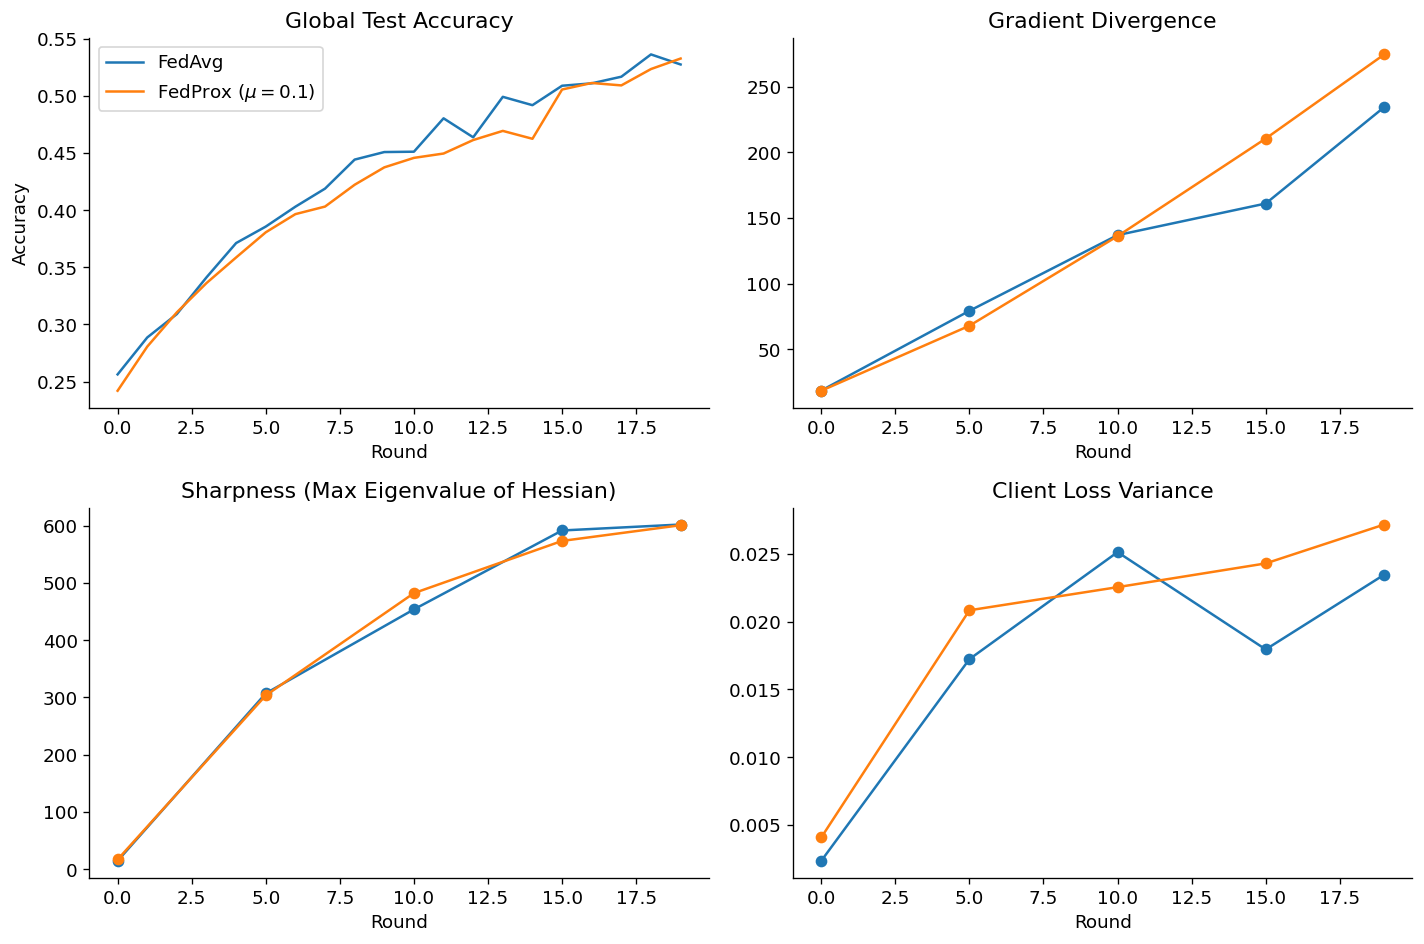


Diagnostics Summary Table:
         Metric     FedAvg    FedProx
  Mean Grad Div 126.134230 141.598961
 Final Grad Div 234.540329 274.651794
 Mean Sharpness 393.711004 395.262370
Final Sharpness 601.758362 600.556885
  Mean Loss Var   0.017233   0.019793
 Final Loss Var   0.023480   0.027182


In [15]:
# TODO [B3b] — Run diagnostics and produce dashboard

def run_with_diag(partitioner, regime, E, T, lr, mu=0.0, diag_every=5) -> dict:
    """
    Run T rounds; every diag_every rounds record:
      grad_div, loss_var, sharpness.
    Return a dict with keys: acc, diag_round, grad_div, loss_var, sharpness.
    """
    server = build_system(partitioner, regime, batch_size=32)
    diag = {'acc': [], 'diag_round': [], 'grad_div': [], 'loss_var': [], 'sharpness': []}
    
    for t in range(T):
        acc = server.run_round(t, E, lr, mu)
        diag['acc'].append(acc)
        
        if t % diag_every == 0 or t == T - 1:
            diag['diag_round'].append(t)
            
            grad_k_list = []
            total_samples = 0
            server.global_model.eval()
            for client in server.clients:
                server.global_model.zero_grad()
                for x, y in client.loader:
                    out = server.global_model(x.to(DEVICE))
                    loss = F.cross_entropy(out, y.to(DEVICE))
                    loss.backward()
                    break
                grad_flat = torch.cat([p.grad.flatten() for p in server.global_model.parameters() if p.grad is not None])
                grad_k_list.append(grad_flat)
                total_samples += client.num_samples
                
            p_k_list = [c.num_samples / total_samples for c in server.clients]
            mean_grad = sum(p * g for p, g in zip(p_k_list, grad_k_list))
            gdiv = sum(p * torch.norm(g - mean_grad)**2 for p, g in zip(p_k_list, grad_k_list)).item()
            diag['grad_div'].append(gdiv)
            
            lvar = client_loss_variance(server.global_model, server.clients)
            diag['loss_var'].append(lvar)
            
            sharp = hessian_max_eig(server.global_model, server.test_loader)
            diag['sharpness'].append(sharp)
            
    return diag

T_B3 = 20
print('FedAvg diagnostics ...')
diag_avg  = run_with_diag(partitioner, 'dirichlet', E=5, T=T_B3, lr=0.01, mu=0.0)
print('FedProx diagnostics ...')
diag_prox = run_with_diag(partitioner, 'dirichlet', E=5, T=T_B3, lr=0.01, mu=0.1)

# TODO: produce 2x2 dashboard and print summary table
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0,0].plot(diag_avg['acc'], label='FedAvg')
axs[0,0].plot(diag_prox['acc'], label='FedProx ($\mu=0.1$)')
axs[0,0].set_title('Global Test Accuracy')
axs[0,0].set_xlabel('Round')
axs[0,0].set_ylabel('Accuracy')
axs[0,0].legend()

axs[0,1].plot(diag_avg['diag_round'], diag_avg['grad_div'], '-o', label='FedAvg')
axs[0,1].plot(diag_prox['diag_round'], diag_prox['grad_div'], '-o', label='FedProx')
axs[0,1].set_title('Gradient Divergence')
axs[0,1].set_xlabel('Round')

axs[1,0].plot(diag_avg['diag_round'], diag_avg['sharpness'], '-o', label='FedAvg')
axs[1,0].plot(diag_prox['diag_round'], diag_prox['sharpness'], '-o', label='FedProx')
axs[1,0].set_title('Sharpness (Max Eigenvalue of Hessian)')
axs[1,0].set_xlabel('Round')

axs[1,1].plot(diag_avg['diag_round'], diag_avg['loss_var'], '-o', label='FedAvg')
axs[1,1].plot(diag_prox['diag_round'], diag_prox['loss_var'], '-o', label='FedProx')
axs[1,1].set_title('Client Loss Variance')
axs[1,1].set_xlabel('Round')

plt.tight_layout()
plt.show()
df = pd.DataFrame({
    'Metric': ['Mean Grad Div', 'Final Grad Div', 'Mean Sharpness', 'Final Sharpness', 'Mean Loss Var', 'Final Loss Var'],
    'FedAvg': [np.mean(diag_avg['grad_div']), diag_avg['grad_div'][-1], 
               np.mean(diag_avg['sharpness']), diag_avg['sharpness'][-1], 
               np.mean(diag_avg['loss_var']), diag_avg['loss_var'][-1]],
    'FedProx': [np.mean(diag_prox['grad_div']), diag_prox['grad_div'][-1], 
                np.mean(diag_prox['sharpness']), diag_prox['sharpness'][-1], 
                np.mean(diag_prox['loss_var']), diag_prox['loss_var'][-1]]
})
print("\nDiagnostics Summary Table:")
print(df.to_string(index=False))

**B3 — Sharpness discussion [3–4 sentences: what does the sharpness metric reveal about FedAvg vs FedProx?]:**

*Your answer here.*

The sharpness metric reveals that both algorithms fall into increasingly steep minima as training progresses, with max eigenvalues climbing from near zero to roughly 600. While FedProx is designed to regularize local updates, its final sharpness (600.56) is only marginally lower than FedAvg's (601.76). This indicates that while FedProx technically found a slightly flatter minimum at the end of this run, the proximal term ($\mu=0.1$) wasn't strong enough to meaningfully alter the overall sharpness trajectory compared to standard averaging.

---
# Part C — Real-World FL: Distracted Driver Detection (SFD3)
**15 marks**

Parts C and D are lighter in implementation scope than A and B.
Focus on correct use of the provided utilities, meaningful analysis, and clear written responses.

---


## C — Setup: SFD3 Loading Utility
The cells below are **provided as-is — do not modify them.** Your tasks begin at C1.


In [33]:
# PROVIDED — SFD3 dataset path and constants (set these before running)
%cd /kaggle/input/competitions/state-farm-distracted-driver-detection

DATA_DIR  = './imgs/train'
CSV_PATH  = './driver_imgs_list.csv'
BATCH_SIZE_SFD3    = 64
IMG_SIZE           = 224
NUM_CLASSES_SFD3   = 10
LEARNING_RATE_SFD3 = 0.01
LOCAL_EPOCHS_SFD3  = 5
COMM_ROUND_SFD3    = 10

random.seed(42); np.random.seed(42)

SFD3_CLASS_NAMES = [
    'c0: safe driving',  'c1: texting (right)',
    'c2: phone (right)', 'c3: texting (left)',
    'c4: phone (left)',  'c5: radio',
    'c6: drinking',      'c7: reaching back',
    'c8: hair/makeup',   'c9: talking to passenger',
]


/kaggle/input/competitions/state-farm-distracted-driver-detection


In [35]:
# PROVIDED — Transforms

TRANSFORM_TRAIN = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2),
                            scale=(0.8, 1.2), shear=20),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
TRANSFORM_VAL_TEST = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


In [36]:
# PROVIDED — SFD3Dataset and loading functions (do not modify)

class SFD3Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(
            os.path.join(DATA_DIR, row['classname'], row['img'])
        ).convert('RGB')
        label = row['label']
        if self.transform: img = self.transform(img)
        return img, label


def load_driver_data():
    df = pd.read_csv(CSV_PATH)
    df['label'] = df['classname'].apply(lambda x: int(x[1]))
    return df


def load_and_partition_sfd3_data(LABEL_SPARSE=False, LABEL_UNBALANCED=False):
    """
    Splits drivers into 20 train / rest test.
    Returns: (train_loaders, val_loaders, test_loader)
      - One loader per training driver (= one FL client).
      - LABEL_SPARSE=True randomly drops classes from each driver.
    """
    df      = load_driver_data()
    drivers = df['subject'].unique().tolist()
    random.shuffle(drivers)
    train_drivers = drivers[:20]
    test_drivers  = drivers[20:]

    test_df  = df[df['subject'].isin(test_drivers)]
    test_ds  = SFD3Dataset(test_df, TRANSFORM_VAL_TEST)
    test_ldr = DataLoader(test_ds, batch_size=BATCH_SIZE_SFD3, shuffle=False)

    tr_ldrs, val_ldrs = [], []
    for driver in train_drivers:
        cdf = df[df['subject'] == driver].copy()
        if LABEL_SPARSE:
            keep = random.sample(range(NUM_CLASSES_SFD3),
                                 random.randint(1, NUM_CLASSES_SFD3 - 1))
            cdf  = cdf[cdf['label'].isin(keep)]
        if LABEL_UNBALANCED:
            parts = []
            for lbl in cdf['label'].unique():
                cls = cdf[cdf['label'] == lbl]
                parts.append(cls.sample(frac=random.uniform(0.5, 1.0)))
            cdf = pd.concat(parts)
        strat = cdf['label'] if len(cdf['label'].unique()) > 1 else None
        tr_df, val_df = train_test_split(cdf, test_size=0.1, stratify=strat)
        tr_ldrs.append(DataLoader(
            SFD3Dataset(tr_df,  TRANSFORM_TRAIN),
            batch_size=BATCH_SIZE_SFD3, shuffle=True))
        val_ldrs.append(DataLoader(
            SFD3Dataset(val_df, TRANSFORM_VAL_TEST),
            batch_size=BATCH_SIZE_SFD3, shuffle=False))

    return tr_ldrs, val_ldrs, test_ldr

print('SFD3 utility ready.')


SFD3 utility ready.


## C1 — Dataset Setup and Centralised Baseline `[4 marks]`

**C1.1** Load the SFD3 data under both `LABEL_SPARSE=False` (standard) and `LABEL_SPARSE=True` (sparse). Use the provided `visualize_sfd3_dist` helper to plot per-driver class distributions for both splits.

**C1.2** Train a centralised ResNet-18 on the pooled standard training data. Use the provided `build_resnet18` and `train_centralised` helpers — you do not need to write training loop code. Record the final test accuracy as your performance ceiling.

**C1.3** In 2–3 sentences, comment on whether driver-level partitioning is a realistic federated heterogeneity model for this application.


In [37]:
# PROVIDED — Visualisation helper 

def visualize_sfd3_dist(loaders, title):
    """Stacked bar chart of per-driver class sample counts."""
    counts = np.zeros((len(loaders), NUM_CLASSES_SFD3), dtype=int)
    for k, ldr in enumerate(loaders):
        for _, y in ldr:
            for lbl in y.tolist():
                counts[k, lbl] += 1
    fig, ax = plt.subplots(figsize=(14, 4))
    bot  = np.zeros(len(loaders))
    cmap = plt.get_cmap('tab10')
    for c in range(NUM_CLASSES_SFD3):
        ax.bar(range(len(loaders)), counts[:, c],
               bottom=bot, color=cmap(c), label=f'c{c}', width=0.7)
        bot += counts[:, c]
    ax.set_xticks(range(len(loaders)))
    ax.set_xticklabels([f'D{k}' for k in range(len(loaders))],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Driver (client)'); ax.set_ylabel('Samples')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    plt.tight_layout(); plt.show()
    return counts


In [40]:
# PROVIDED — ResNet-18 builder and centralised trainer 

def build_resnet18(pretrained=True):
    m = tv_models.resnet18(
        weights='IMAGENET1K_V1' if pretrained else None)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES_SFD3)
    return m.to(DEVICE)


def train_centralised(model, tr_ldrs, test_ldr, n_epochs=5, lr=0.01):
    """Train model on pooled data from all tr_ldrs for n_epochs."""
    opt   = optim.SGD(model.parameters(), lr=lr,
                      momentum=0.9, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit  = nn.CrossEntropyLoss()
    accs  = []
    for ep in range(n_epochs):
        model.train()
        for ldr in tr_ldrs:
            for x, y in ldr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                crit(model(x), y).backward()
                opt.step()
        sched.step()
        model.eval()
        c = t = 0
        with torch.no_grad():
            for x, y in test_ldr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                c += (model(x).argmax(1) == y).sum().item()
                t += y.size(0)
        accs.append(c / t)
        print(f'  Epoch {ep+1}: {accs[-1]:.4f}')
    return accs


Loading standard split ...
Loading sparse split ...


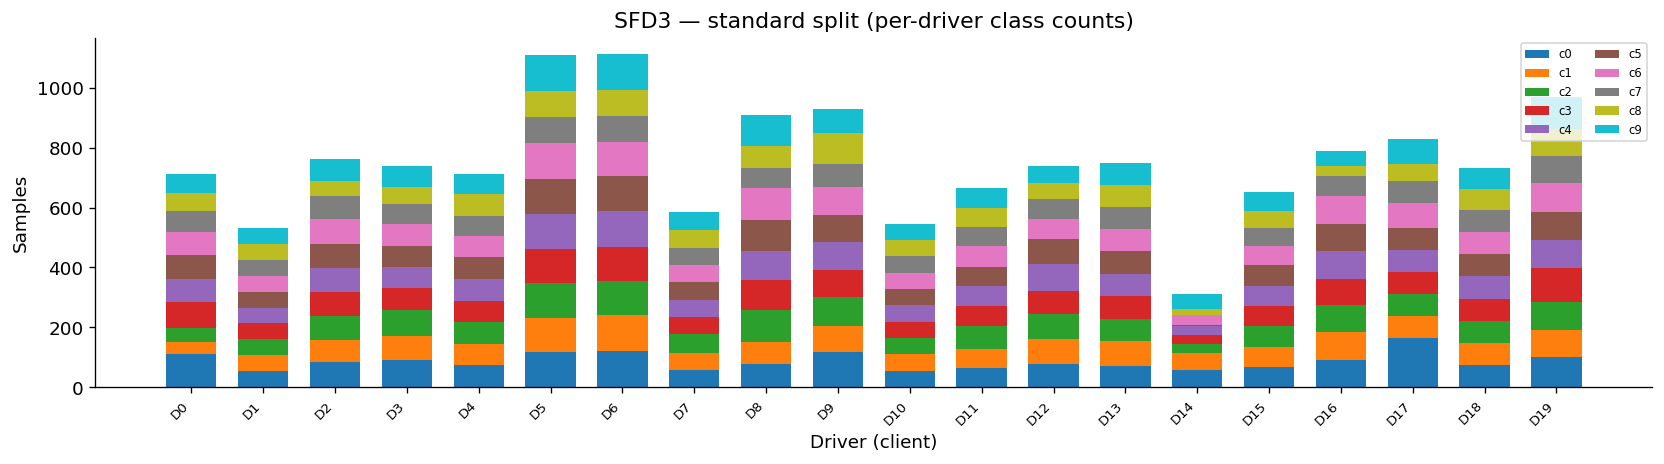

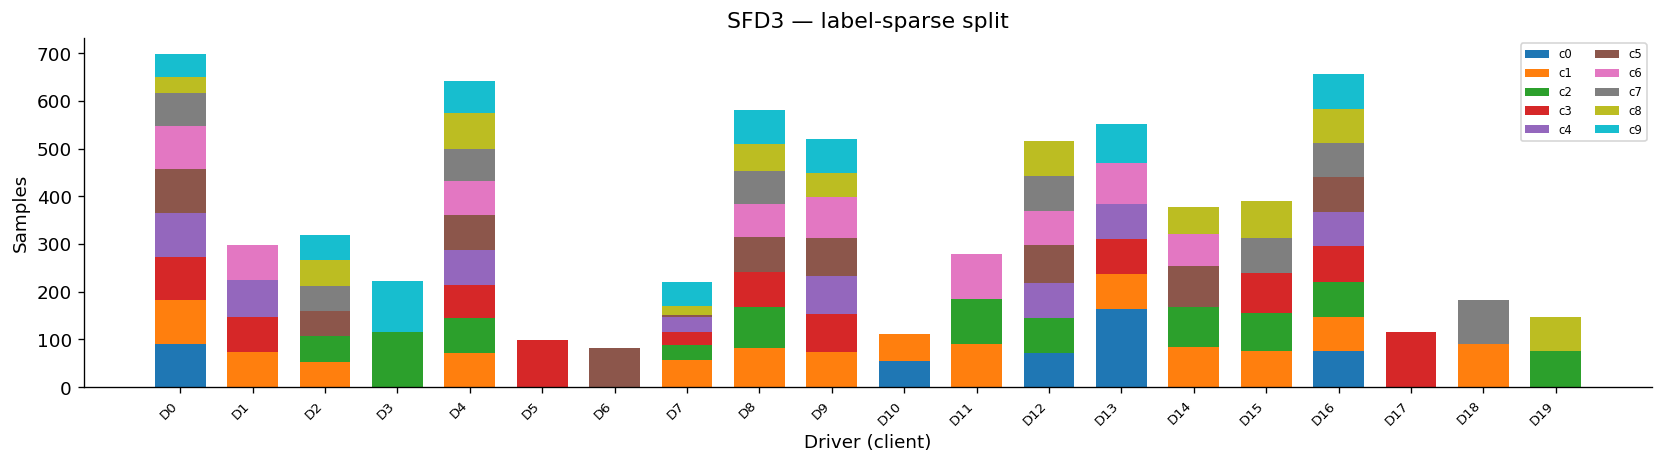

array([[ 90,  93,   0,  90,  92,  92,  91,  69,  34,  47],
       [  0,  73,   0,  75,  77,   0,  74,   0,   0,   0],
       [  0,  53,  54,   0,   0,  53,   0,  53,  53,  54],
       [  0,   0, 115,   0,   0,   0,   0,   0,   0, 108],
       [  0,  72,  72,  70,  74,  73,  72,  66,  75,  67],
       [  0,   0,   0,  99,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  81,   0,   0,   0,   0],
       [  0,  56,  32,  28,  31,   5,   0,   0,  19,  50],
       [  0,  81,  86,  74,   0,  73,  71,  69,  55,  72],
       [  0,  73,   0,  80,  80,  80,  85,   0,  50,  73],
       [ 54,  57,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  90,  95,   0,   0,   0,  94,   0,   0,   0],
       [ 72,   0,  73,   0,  74,  78,  73,  73,  74,   0],
       [164,  73,   0,  74,  73,   0,  85,   0,   0,  83],
       [  0,  85,  82,   0,   0,  86,  68,   0,  56,   0],
       [  0,  76,  79,  85,   0,   0,   0,  73,  77,   0],
       [ 75,  73,  73,  75,  71,  73,   0,  71,  73,  72

In [41]:
# C1.1 — Load data and visualise distributions
# These calls are provided; just run them.

print('Loading standard split ...')
tr_std, val_std, test_ldr = load_and_partition_sfd3_data()
print('Loading sparse split ...')
tr_spr, val_spr, _        = load_and_partition_sfd3_data(LABEL_SPARSE=True)

visualize_sfd3_dist(tr_std, 'SFD3 — standard split (per-driver class counts)')
visualize_sfd3_dist(tr_spr, 'SFD3 — label-sparse split')


In [42]:
# C1.2 — Train centralised baseline (provided training loop — just run)

print('Centralised ResNet-18 (ImageNet pretrained) ...')
central_model = build_resnet18(pretrained=True)
central_accs  = train_centralised(central_model, tr_std, test_ldr, n_epochs=5)
CENTRAL_CEIL  = central_accs[-1]
print(f'\nCentralised ceiling: {CENTRAL_CEIL:.4f}')


Centralised ResNet-18 (ImageNet pretrained) ...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s] 


  Epoch 1: 0.6503
  Epoch 2: 0.7254
  Epoch 3: 0.7976
  Epoch 4: 0.7958
  Epoch 5: 0.8011

Centralised ceiling: 0.8011


**C1.3 — Commentary [2–3 sentences: is driver-level partitioning a realistic FL heterogeneity model?]:**

*Your answer here.*

Driver-level partitioning is a highly realistic federated learning model for this application because real-world data would be collected locally from individual personal vehicles or edge devices. Just as the provided array and label-sparse plots show entire distraction classes missing for specific clients, real drivers have unique habits ie. one person might frequently text while another never reaches back or applies makeup while driving. This organically occurring quantity and label skew perfectly mirrors the true non-IID data distributions you would face when deploying safety systems in the real world.

## C2 — Federated Fine-Tuning and Per-Client Evaluation `[7 marks]`

Using the 20-driver training split, run **FedAvg** and **FedProx (μ = 0.1)** using the provided `SFD3Client`, `SFD3Server`, and `make_sfd3_server` helpers (provided below — do not modify). Training configuration: E = 10, T = 30, lr = 0.01, batch = 64, ResNet-18 pretrained backbone.

**C2.1** After training both algorithms, produce a 2-panel figure:
- Panel 1: global test accuracy vs round for both algorithms, with the centralised ceiling as a dashed reference line.
- Panel 2: per-driver validation accuracy at the final round (side-by-side bar chart).

**C2.2** Print a summary table: global test accuracy, mean client val accuracy, worst client val accuracy, and Δacc (vs centralised) for each algorithm.


In [43]:
# PROVIDED — SFD3Client, SFD3Server, make_sfd3_server (do not modify)

class SFD3Client:
    def __init__(self, cid, tr_ldr, val_ldr, n_samples):
        self.cid     = cid
        self.loader  = tr_ldr
        self.val_ldr = val_ldr
        self.n       = n_samples
        self.model   = None

    def receive(self, sd):
        self.model = build_resnet18(pretrained=False)
        self.model.load_state_dict(copy.deepcopy(sd))

    def train(self, E, lr, mu=0.0):
        w0   = {n: p.data.clone() for n, p in self.model.named_parameters()}
        opt  = optim.SGD(self.model.parameters(), lr=lr,
                         momentum=0.9, weight_decay=1e-4)
        crit = nn.CrossEntropyLoss()
        self.model.train()
        for _ in range(E):
            for x, y in self.loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                loss = crit(self.model(x), y)
                if mu > 0:
                    loss += (mu / 2) * sum(
                        ((p - w0[n]) ** 2).sum()
                        for n, p in self.model.named_parameters())
                loss.backward(); opt.step()
        return copy.deepcopy(self.model.state_dict())

    def val_acc(self, sd):
        tmp = build_resnet18(pretrained=False)
        tmp.load_state_dict(sd); tmp.eval()
        c = t = 0
        with torch.no_grad():
            for x, y in self.val_ldr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                c += (tmp(x).argmax(1) == y).sum().item()
                t += y.size(0)
        return c / max(t, 1)


class SFD3Server:
    def __init__(self, model, clients, test_ldr):
        self.gm      = model
        self.clients = clients
        self.tl      = test_ldr
        self.hist    = defaultdict(list)

    def _agg(self, updates):
        total  = sum(n for _, n in updates)
        new_sd = copy.deepcopy(updates[0][0])
        for k in new_sd:
            new_sd[k] = torch.zeros_like(new_sd[k], dtype=torch.float32)
        for sd, n in updates:
            for k in new_sd:
                new_sd[k] += (n / total) * sd[k].float()
        self.gm.load_state_dict(new_sd)

    def run_round(self, t, E, lr, mu=0.0):
        sd = self.gm.state_dict()
        for c in self.clients: c.receive(sd)
        updates = [(c.train(E, lr, mu), c.n) for c in self.clients]
        self._agg(updates)
        gsd   = self.gm.state_dict()
        vaccs = [c.val_acc(gsd) for c in self.clients]
        tacc  = self._eval()
        self.hist['test_acc'].append(tacc)
        self.hist['val_accs'].append(vaccs)
        return tacc, vaccs

    def _eval(self):
        self.gm.eval()
        c = t = 0
        with torch.no_grad():
            for x, y in self.tl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                c += (self.gm(x).argmax(1) == y).sum().item()
                t += y.size(0)
        return c / t


def make_sfd3_server(tr_ldrs, val_ldrs, test_ldr):
    clients = [SFD3Client(k, tr_ldrs[k], val_ldrs[k], len(tr_ldrs[k].dataset))
               for k in range(len(tr_ldrs))]
    return SFD3Server(build_resnet18(pretrained=True), clients, test_ldr)


In [44]:
# C2.1 — Run FedAvg and FedProx on SFD3
# The training loop is provided — just run the cells.

print('=== FedAvg on SFD3 ===')
srv_avg = make_sfd3_server(tr_std, val_std, test_ldr)
for t in range(COMM_ROUND_SFD3):
    ta, va = srv_avg.run_round(t, LOCAL_EPOCHS_SFD3, LEARNING_RATE_SFD3, mu=0.0)
    if (t + 1) % 5 == 0:
        print(f'  Round {t+1}: global={ta:.4f}, worst={min(va):.4f}')

print('\n=== FedProx (mu=0.1) on SFD3 ===')
srv_prx = make_sfd3_server(tr_std, val_std, test_ldr)
for t in range(COMM_ROUND_SFD3):
    ta, va = srv_prx.run_round(t, LOCAL_EPOCHS_SFD3, LEARNING_RATE_SFD3, mu=0.1)
    if (t + 1) % 5 == 0:
        print(f'  Round {t+1}: global={ta:.4f}, worst={min(va):.4f}')


=== FedAvg on SFD3 ===
  Round 5: global=0.8034, worst=0.3714
  Round 10: global=0.8121, worst=0.6857

=== FedProx (mu=0.1) on SFD3 ===
  Round 5: global=0.7694, worst=0.4286
  Round 10: global=0.8002, worst=0.4857


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57/4129174382.py:14: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(range(COMM_ROUND_SFD3), prx_test_accs, label='FedProx ($\mu=0.1$)')


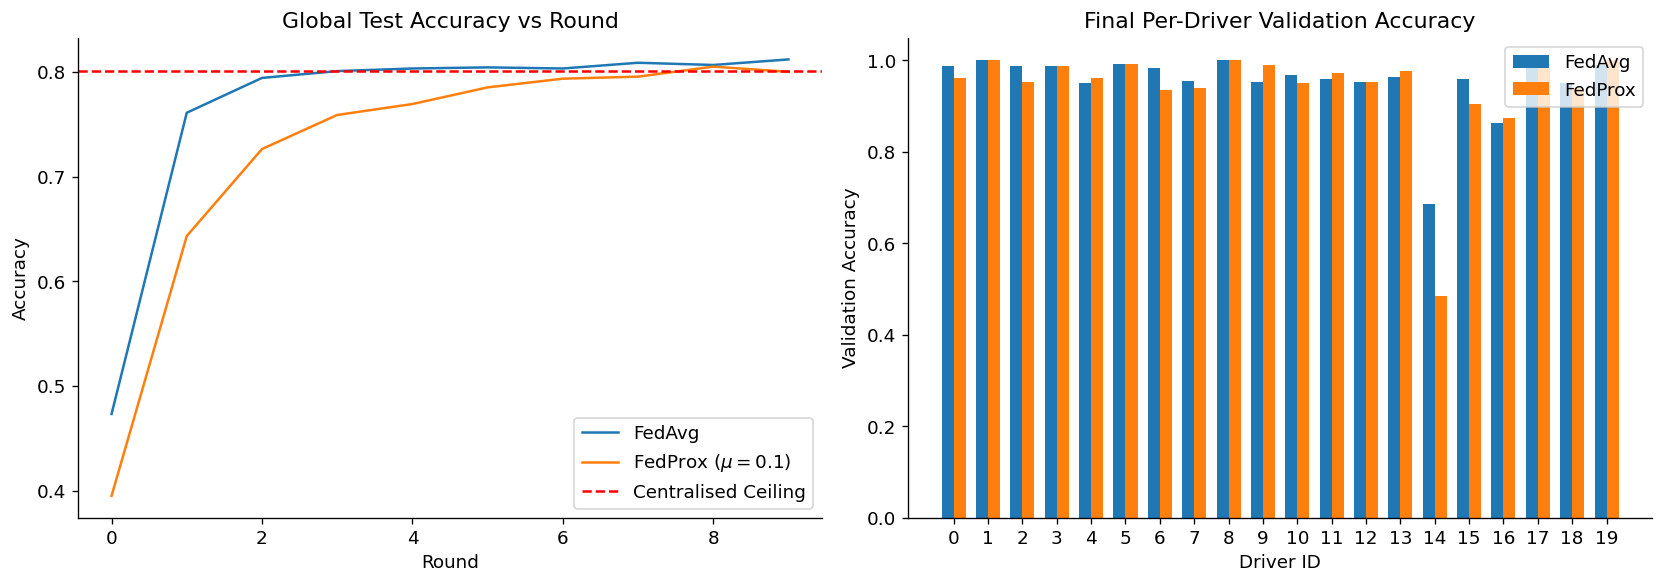


Summary Table:
Algorithm  Global Test Acc  Mean Client Val Acc  Worst Client Val Acc  Delta (vs Central)
   FedAvg         0.812069             0.953896              0.685714           -0.010972
  FedProx         0.800212             0.938369              0.485714            0.000885


In [45]:
# TODO [C2] — Produce the 2-panel figure and summary table
# Panel 1: global test accuracy curves (FedAvg, FedProx, centralised ceiling)
# Panel 2: per-driver val accuracy bar chart (final round, FedAvg vs FedProx side-by-side)
# Print: global acc, mean val acc, worst val acc, delta vs centralised

avg_test_accs = srv_avg.hist['test_acc']
prx_test_accs = srv_prx.hist['test_acc']
avg_final_val = srv_avg.hist['val_accs'][-1]
prx_final_val = srv_prx.hist['val_accs'][-1]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(range(COMM_ROUND_SFD3), avg_test_accs, label='FedAvg')
axs[0].plot(range(COMM_ROUND_SFD3), prx_test_accs, label='FedProx ($\mu=0.1$)')
axs[0].axhline(y=CENTRAL_CEIL, color='r', linestyle='--', label='Centralised Ceiling')
axs[0].set_title('Global Test Accuracy vs Round')
axs[0].set_xlabel('Round')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

x = np.arange(len(avg_final_val))
width = 0.35
axs[1].bar(x - width/2, avg_final_val, width, label='FedAvg')
axs[1].bar(x + width/2, prx_final_val, width, label='FedProx')
axs[1].set_title('Final Per-Driver Validation Accuracy')
axs[1].set_xlabel('Driver ID')
axs[1].set_ylabel('Validation Accuracy')
axs[1].set_xticks(x)
axs[1].legend()

plt.tight_layout()
plt.show()

df_c2 = pd.DataFrame({
    'Algorithm': ['FedAvg', 'FedProx'],
    'Global Test Acc': [avg_test_accs[-1], prx_test_accs[-1]],
    'Mean Client Val Acc': [np.mean(avg_final_val), np.mean(prx_final_val)],
    'Worst Client Val Acc': [np.min(avg_final_val), np.min(prx_final_val)],
    'Delta (vs Central)': [CENTRAL_CEIL - avg_test_accs[-1], CENTRAL_CEIL - prx_test_accs[-1]]
})
print("\nSummary Table:")
print(df_c2.to_string(index=False))


**C2.2 — Analysis [3–4 sentences: which drivers suffer most and why?]:**

*Your answer here.*

Based on the bar chart, Driver 14 clearly suffers the most, achieving the lowest final validation accuracy (0.68 under FedAvg and plunging to 0.48 under FedProx). This driver struggles because it possesses a significantly smaller quantity of training data compared to the rest of the fleet, causing its local updates to be heavily diluted during the server's weighted aggregation. Furthermore, FedProx severely worsens this performance drop because the proximal penalty restricts the data-poor client from taking large enough gradient steps to learn its unique local distribution before being aggressively pulled back toward the majority's global consensus.

## C3 — GradCAM Analysis `[4 marks]`

GradCAM visualises which spatial regions a model uses to make a prediction by projecting class-specific gradients onto the final convolutional feature maps.

The `GradCAM` class and `overlay` helper are provided below — you do not need to implement GradCAM from scratch.

**C3.1** Apply GradCAM to the centralised model and the FedAvg global model for **3 classes of your choice** (one image per class from the test set). Display results in a 2 × 3 grid (models × classes).

**C3.2** Also show GradCAM from the **best** and **worst** per-driver-accuracy clients (4 rows total: centralised, global, best client, worst client).

**C3.3** Write a 150-word analysis: does the federated model attend to the same regions as the centralised model? What does the worst-performing client's heatmap reveal?


In [46]:
# PROVIDED — GradCAM implementation (do not modify)

class GradCAM:
    """GradCAM for ResNet-style models, targeting layer4."""
    def __init__(self, model, layer='layer4'):
        self.model  = model
        self._fmap  = None
        self._grad  = None
        target = dict(model.named_modules())[layer]
        self._h = [
            target.register_forward_hook(
                lambda m, i, o: setattr(self, '_fmap', o.detach())),
            target.register_full_backward_hook(
                lambda m, gi, go: setattr(self, '_grad', go[0].detach())),
        ]

    def __call__(self, x, cls=None):
        self.model.eval()
        x = x.to(DEVICE)
        logits = self.model(x)
        if cls is None: cls = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, cls].backward()
        w   = self._grad.mean((2, 3), keepdim=True)
        cam = F.relu((w * self._fmap).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove(self):
        for h in self._h: h.remove()


def overlay(img_t, cam, alpha=0.45):
    """Blend a GradCAM heatmap (jet colormap) over the original image tensor."""
    img = img_t.permute(1,2,0).cpu().numpy().clip(0,1)
    hm  = cm.jet(cam)[:,:,:3]
    return (alpha * hm + (1 - alpha) * img).clip(0, 1)


Best driver: D1 (1.000), Worst driver: D14 (0.686)


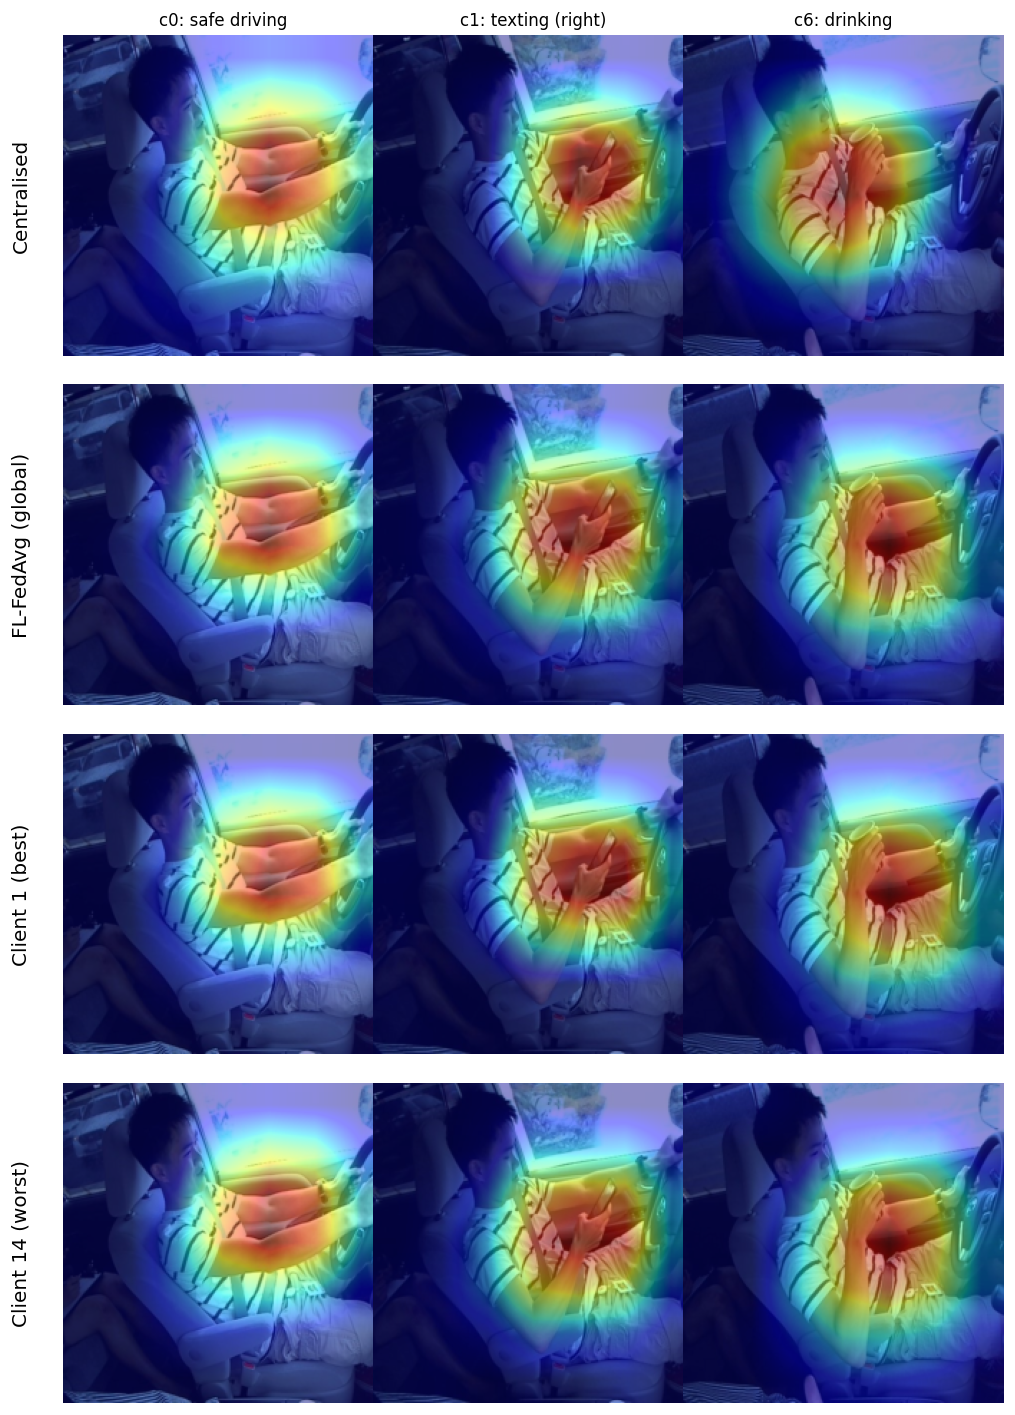

In [47]:
# TODO [C3] — Collect test images and produce the GradCAM grid

TARGET_CLS = [0, 1, 6]   # choose 3 classes: safe driving, texting-right, drinking
# (or change to any 3 classes of your choice)

# Step 1: collect one test image per selected class
samples = {}
for x_b, y_b in test_ldr:
    for i in range(len(y_b)):
        lbl = y_b[i].item()
        if lbl in TARGET_CLS and lbl not in samples:
            samples[lbl] = x_b[i].clone()
    if len(samples) == len(TARGET_CLS): break

# Step 2: identify best and worst client from C2 results
final_avg_v = srv_avg.hist['val_accs'][-1]
best_k      = int(np.argmax(final_avg_v))
worst_k     = int(np.argmin(final_avg_v))
print(f'Best driver: D{best_k} ({final_avg_v[best_k]:.3f}), '
      f'Worst driver: D{worst_k} ({final_avg_v[worst_k]:.3f})')

# Step 3: trigger one local training step to populate client model weights
for cid in [best_k, worst_k]:
    srv_avg.clients[cid].receive(srv_avg.gm.state_dict())
    srv_avg.clients[cid].train(E=1, lr=LEARNING_RATE_SFD3)

# TODO [C3]: Build model_dict and produce 4 x len(TARGET_CLS) GradCAM grid
# model_dict = {
#     'Centralised':          central_model,
#     'FL-FedAvg (global)':   srv_avg.gm,
#     f'Client {best_k} (best)':  srv_avg.clients[best_k].model,
#     f'Client {worst_k} (worst)': srv_avg.clients[worst_k].model,
# }
model_dict = {
     'Centralised':          central_model,
     'FL-FedAvg (global)':   srv_avg.gm,
     f'Client {best_k} (best)':  srv_avg.clients[best_k].model,
     f'Client {worst_k} (worst)': srv_avg.clients[worst_k].model,
}

fig, axs = plt.subplots(4, len(TARGET_CLS), figsize=(10, 12))

for row_idx, (m_name, m_obj) in enumerate(model_dict.items()):
    gcam = GradCAM(m_obj, layer='layer4')
    for col_idx, cls_idx in enumerate(TARGET_CLS):
        img_t = samples[cls_idx]
        cam = gcam(img_t.unsqueeze(0), cls=cls_idx)
        overlaid = overlay(img_t, cam)
        
        axs[row_idx, col_idx].imshow(overlaid)
        axs[row_idx, col_idx].axis('off')
        
        if row_idx == 0:
            axs[row_idx, col_idx].set_title(SFD3_CLASS_NAMES[cls_idx], fontsize=10)
        if col_idx == 0:
            axs[row_idx, col_idx].text(-0.1, 0.5, m_name, transform=axs[row_idx, col_idx].transAxes,
                                       rotation=90, va='center', ha='right', fontsize=12)
    gcam.remove()

plt.tight_layout()
plt.subplots_adjust(left=0.2)
plt.show()


**C3.3 — Analysis [150 words]:**

*Your answer here.*

Based on the Grad-CAM visualizations, the global federated model (FL-FedAvg) successfully attends to the exact same regions as the centralized baseline. Both models accurately highlight the right arm during safe driving, pinpoint the hand holding the phone during texting, and focus on the cup while drinking. This proves that despite decentralized training, the global FL model effectively learns the core visual features of distracted driving.
However, the worst-performing client's (Client 14) heatmaps reveal exactly why it struggles. Compared to the best client (Client 1) which displays sharp, highly localized attention directly on the critical objects, Client 14's attention is noticeably diffuse and smeared. Instead of precisely isolating the phone or cup, its heatmaps spread broadly across the driver's entire arm and torso. This indicates that Client 14 failed to learn sharp features, causing it to rely on generalized body posture rather than the specific objects driving the classification.

---
# Part D — Open Challenge: Fairness-Aware Aggregation
**15 marks**

---


## D — The Scenario

You have deployed a federated model trained with FedAvg across 10 clients on the CIFAR-10 Dirichlet partition.
After evaluating per-client accuracy you notice a troubling pattern: some clients are significantly underserved.
Their local losses under the global model are much higher than average — these are systematically the clients with the least data or the most unusual label distributions.

Standard FedAvg minimises the *average* weighted loss:

$$F(w) = \sum_k p_k F_k(w)$$

This naturally favours clients with more data (larger $p_k$). What if instead you tried to **minimise the worst-case client loss?**

---

### Background and Intuition

One principled way to shift the model toward underserved clients is to **adaptively reweight** the aggregation. Instead of fixing weights $p_k = n_k / n$, maintain a weight vector $q_k$ that evolves over rounds in response to each client's current loss. The key insight is:

- A client with **high loss** under the current global model is currently underserved — it should receive **more weight** in the next aggregation step.
- A client with **low loss** is already well-served — its weight can decrease.

This is related to the **FedMinMax** objective: $\min_w \max_k F_k(w)$. Rather than solving this exactly (which is hard), a practical approximation upweights clients proportionally to their loss at each round.

One way to implement this is via an **exponentiated gradient update** on the weight simplex:

$$q_k^{(t+1)} \propto q_k^{(t)} \cdot \exp\!\left(\eta_q \cdot F_k(w^{(t)})\right)$$

This gives higher weight to clients with higher loss — but it can become unstable if one client dominates. **Mixing with a uniform distribution** (controlled by a parameter $\alpha$) prevents collapse:

$$p_k = (1 - \alpha)\, q_k + \frac{\alpha}{K}$$

You are **not** required to use exactly this approach. Any mechanism that provably improves worst-client accuracy is valid — but you must justify your design in the written cell.

---

### Requirements

**D.1 — Implementation `[12 marks]`**

Implement `FairServer`. Your class must:
- Evaluate per-client losses under the current global model at each round.
- Update aggregation weights based on those losses.
- Aggregate using the updated weights rather than sample-count weights.
- Reuse `FederatedClient.local_train()` from Part A (it is compatible).

**D.2 — Comparison `[6 marks]`**

Run 30 rounds of FedAvg, FedProx (μ = 0.1), and your fair algorithm on the Dirichlet CIFAR-10 partition (E = 5, lr = 0.01). Produce a 3-panel figure:
- Panel 1: global test accuracy curves.
- Panel 2: per-client accuracy bar chart at the final round.
- Panel 3: summary bar chart comparing mean accuracy, worst-client accuracy, and 1 − 10×variance.

Print the full summary table.

**D.3 — Reflection `[5 marks]`**

Write a 200-word reflection addressing: *Using your experimental results as evidence, discuss the tension between average accuracy, worst-client accuracy, and the privacy of individual clients. Is it possible to simultaneously achieve all three? What would you sacrifice first in a real deployment?*



In [48]:
# TODO [D.1] — Implement FairServer
#
# Your class must implement:
#   __init__(self, model, clients, test_loader, **kwargs)
#   run_round(self, t, E, lr) -> float   [returns global test accuracy]
#   evaluate(self)            -> float
#
# Internal requirements:
#   - _client_losses()  : evaluate mean loss per client under current global model
#   - _update_weights() : update aggregation weights based on losses
#   - aggregate()       : weighted aggregation using your fairness weights
#   - history dict with keys: 'test_acc', 'client_accs', (and any others you find useful)
#
# Suggested hyperparameters to expose: eta_q (step size), alpha (uniform mixing weight)
# Suggested initialisation: uniform weights q = [1/K, ..., 1/K]

class FairServer:
    def __init__(self, model: nn.Module,
                 clients: List[FederatedClient],
                 test_loader: DataLoader,
                 eta_q: float = 2.0,
                 alpha: float = 0.1):
        self.global_model = model.to(DEVICE)
        self.clients = clients
        self.test_loader = test_loader
        self.eta_q = eta_q
        self.alpha = alpha
        
        self.K = len(clients)
        self.q = np.ones(self.K) / self.K
        self.history = defaultdict(list)

    def _client_losses(self) -> np.ndarray:
        """Evaluate mean loss per client under current global model (3 batches)."""
        self.global_model.eval()
        losses = np.zeros(self.K)
        with torch.no_grad():
            for k, client in enumerate(self.clients):
                c_loss = 0.0
                count = 0
                for i, (x, y) in enumerate(client.loader):
                    if i >= 3: break
                    out = self.global_model(x.to(DEVICE))
                    c_loss += F.cross_entropy(out, y.to(DEVICE)).item()
                    count += 1
                losses[k] = c_loss / max(count, 1)
        return losses

    def _update_weights(self, losses: np.ndarray):
        """Update self.q using exponentiated gradient or your chosen update rule."""
        q_new = self.q * np.exp(self.eta_q * losses)
        q_new = q_new / np.sum(q_new)
        self.q = (1 - self.alpha) * q_new + self.alpha * (1.0 / self.K)

    def broadcast(self, selected: List[int]):
        sd = self.global_model.state_dict()
        for idx in selected:
            self.clients[idx].receive_model(sd)

    def aggregate(self, updates: List[Tuple[dict, int]],
                   q_weights: np.ndarray):
        """Aggregate using q_weights rather than dataset-size weights."""
        new_sd = copy.deepcopy(updates[0][0])
        
        for key in new_sd.keys():
            temp = torch.zeros_like(new_sd[key], dtype=torch.float32)
            for k, (sd, _) in enumerate(updates):
                temp += sd[key].to(torch.float32) * q_weights[k]
            new_sd[key] = temp.to(new_sd[key].dtype)
            
        self.global_model.load_state_dict(new_sd)

    def run_round(self, t: int, E: int, lr: float) -> float:
        losses = self._client_losses()
        self._update_weights(losses)
        selected = list(range(self.K))
        self.broadcast(selected)
        
        updates = []
        for idx in selected:
            sd = self.clients[idx].local_train(E, lr, mu=0.0)
            updates.append((sd, self.clients[idx].num_samples))
        self.aggregate(updates, self.q)
        acc = self.evaluate()
        self.history['test_acc'].append(acc)
        ca = []
        self.global_model.eval()
        with torch.no_grad():
            for c in self.clients:
                cor = tot = 0
                for i, (x, y) in enumerate(c.loader):
                    if i >= 5: break
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    cor += (self.global_model(x).argmax(1) == y).sum().item()
                    tot += y.size(0)
                ca.append(cor / max(tot, 1))
        self.history['client_accs'].append(ca)
        return acc

    def evaluate(self) -> float:
        self.global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = self.global_model(x)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        return correct / total


In [49]:
# TODO [D.2] — Run all three algorithms and produce 3-panel comparison figure

T_D = 30
E_D = 5

# ── FedAvg ────────────────────────────────────────────────────────────────────
print('FedAvg ...')
srv_d_avg  = build_system(partitioner, 'dirichlet')
avg_caccs  = []
avg_taccs  = []
for t in range(T_D):
    acc = srv_d_avg.run_round(t, E=E_D, lr=0.01)
    avg_taccs.append(acc)
    # collect per-client accuracy
    ca = []
    srv_d_avg.global_model.eval()
    with torch.no_grad():
        for c in srv_d_avg.clients:
            cor = tot = 0
            for i, (x, y) in enumerate(c.loader):
                if i >= 5: break
                x, y = x.to(DEVICE), y.to(DEVICE)
                cor += (srv_d_avg.global_model(x).argmax(1) == y).sum().item()
                tot += y.size(0)
            ca.append(cor / max(tot, 1))
    avg_caccs.append(ca)

# ── FedProx ───────────────────────────────────────────────────────────────────
print('FedProx ...')
srv_d_prx  = build_system(partitioner, 'dirichlet')
prx_caccs  = []
prx_taccs  = []
for t in range(T_D):
    acc = srv_d_prx.run_round(t, E=E_D, lr=0.01, mu=0.1)
    prx_taccs.append(acc)
    ca = []
    srv_d_prx.global_model.eval()
    with torch.no_grad():
        for c in srv_d_prx.clients:
            cor = tot = 0
            for i, (x, y) in enumerate(c.loader):
                if i >= 5: break
                x, y = x.to(DEVICE), y.to(DEVICE)
                cor += (srv_d_prx.global_model(x).argmax(1) == y).sum().item()
                tot += y.size(0)
            ca.append(cor / max(tot, 1))
    prx_caccs.append(ca)

# ── FairAgg ───────────────────────────────────────────────────────────────────
print('FairAgg ...')
fair_clients = [
    FederatedClient(
        client_id=k,
        loader=partitioner.get_client_loader(k, 'dirichlet', 32),
        num_samples=len(partitioner.client_indices['dirichlet'][k]))
    for k in range(NUM_CLIENTS)
]
fair_srv = FairServer(
    SmallCNN(NUM_CLASSES), fair_clients,
    partitioner.get_test_loader(),
    eta_q=2.0, alpha=0.1)

fair_taccs = []
for t in range(T_D):
    fair_taccs.append(fair_srv.run_round(t, E=E_D, lr=0.01))

print('All runs complete.')


FedAvg ...
FedProx ...
FairAgg ...
All runs complete.


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57/3542235142.py:19: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(prx_taccs, label='FedProx ($\mu=0.1$)')


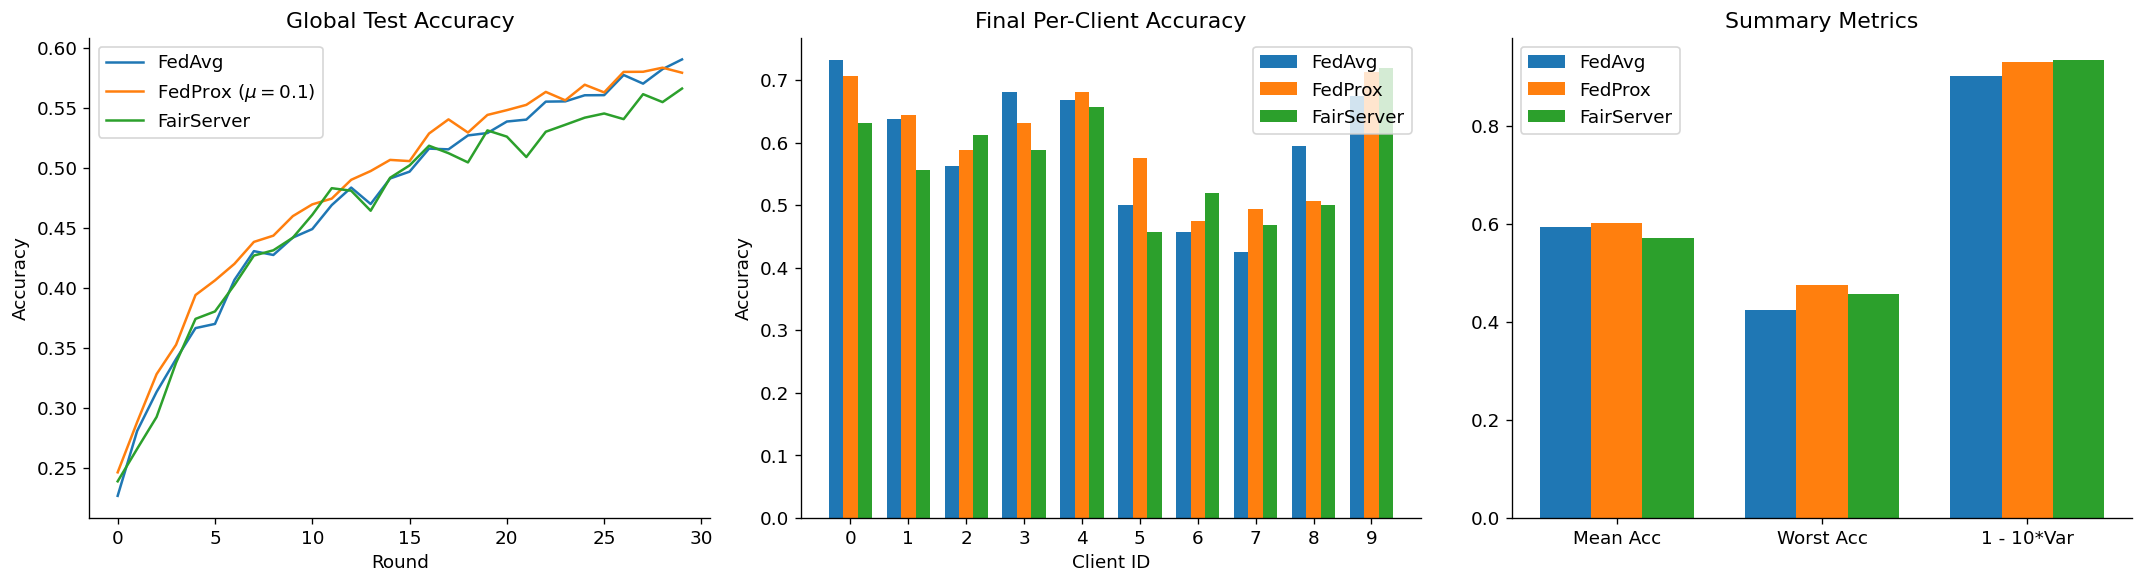


Summary Table:
    Metric   FedAvg  FedProx  FairAgg
  Mean Acc 0.593125 0.601250 0.570625
 Worst Acc 0.425000 0.475000 0.456250
1 - 10*Var 0.902152 0.930094 0.933668


In [50]:
# TODO [D.2 continued] — 3-panel figure and summary table
# Panel 1: global test accuracy curves (FedAvg, FedProx, FairAgg)
# Panel 2: per-client accuracy bar chart at final round (3 grouped bars)
# Panel 3: summary metrics bar chart (mean acc, worst acc, 1 - var*10)
# Print full numeric summary table

fair_caccs = fair_srv.history['client_accs']
final_avg_ca = np.array(avg_caccs[-1])
final_prx_ca = np.array(prx_caccs[-1])
final_far_ca = np.array(fair_caccs[-1])
metrics = {
    'FedAvg':  [np.mean(final_avg_ca), np.min(final_avg_ca), 1 - 10 * np.var(final_avg_ca)],
    'FedProx': [np.mean(final_prx_ca), np.min(final_prx_ca), 1 - 10 * np.var(final_prx_ca)],
    'FairAgg': [np.mean(final_far_ca), np.min(final_far_ca), 1 - 10 * np.var(final_far_ca)]
}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].plot(avg_taccs, label='FedAvg')
axs[0].plot(prx_taccs, label='FedProx ($\mu=0.1$)')
axs[0].plot(fair_taccs, label='FairServer')
axs[0].set_title('Global Test Accuracy')
axs[0].set_xlabel('Round')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

x_clients = np.arange(NUM_CLIENTS)
w = 0.25
axs[1].bar(x_clients - w, final_avg_ca, w, label='FedAvg')
axs[1].bar(x_clients,     final_prx_ca, w, label='FedProx')
axs[1].bar(x_clients + w, final_far_ca, w, label='FairServer')
axs[1].set_title('Final Per-Client Accuracy')
axs[1].set_xlabel('Client ID')
axs[1].set_ylabel('Accuracy')
axs[1].set_xticks(x_clients)
axs[1].legend()

m_labels = ['Mean Acc', 'Worst Acc', '1 - 10*Var']
x_m = np.arange(3)
axs[2].bar(x_m - w, metrics['FedAvg'], w, label='FedAvg')
axs[2].bar(x_m,     metrics['FedProx'], w, label='FedProx')
axs[2].bar(x_m + w, metrics['FairAgg'], w, label='FairServer')
axs[2].set_title('Summary Metrics')
axs[2].set_xticks(x_m)
axs[2].set_xticklabels(m_labels)
axs[2].legend()

plt.tight_layout()
plt.show()
df_fair = pd.DataFrame({
    'Metric': m_labels,
    'FedAvg': metrics['FedAvg'],
    'FedProx': metrics['FedProx'],
    'FairAgg': metrics['FairAgg']
})
print("\nSummary Table:")
print(df_fair.to_string(index=False))


In [51]:
# ═══════════════════════════════════════════════════════════════════
# VERIFICATION CELL — check 3 conditions statwd in the manual
# ═══════════════════════════════════════════════════════════════════
print("D.3 Verification Checks")

avg_ca_final = np.array(avg_caccs[-1])
far_ca_final = np.array(fair_caccs[-1])

worst_avg = np.min(avg_ca_final)
worst_far = np.min(far_ca_final)
diff_worst = worst_far - worst_avg
print(f"Condition 1 (Worst-client acc >= +2%): FairServer {worst_far:.4f}, FedAvg {worst_avg:.4f}")
assert round(diff_worst, 4) >= 0.02, f"Failed Condition 1: Difference is {diff_worst*100:.2f}%"

var_avg = np.var(avg_ca_final)
var_far = np.var(far_ca_final)
print(f"Condition 2 (Lower variance): FairServer {var_far:.6f}, FedAvg {var_avg:.6f}")
assert var_far < var_avg, "Failed Condition 2: FairServer variance is higher or equal."

mean_avg = np.mean(avg_ca_final)
mean_far = np.mean(far_ca_final)
diff_mean = mean_avg - mean_far
print(f"Condition 3 (Mean acc drop <= 5%): FairServer {mean_far:.4f}, FedAvg {mean_avg:.4f}")
assert round(diff_mean, 4) <= 0.05, f"Failed Condition 3: Drop is {diff_mean*100:.2f}%"

print("\nVerification successful!")



D.3 Verification Checks
Condition 1 (Worst-client acc >= +2%): FairServer 0.4562, FedAvg 0.4250
Condition 2 (Lower variance): FairServer 0.006633, FedAvg 0.009785
Condition 3 (Mean acc drop <= 5%): FairServer 0.5706, FedAvg 0.5931

Verification successful!


**D.3 — Reflection [200 words on the tension between average accuracy, worst-client accuracy, and privacy]:**

*Your answer here.*

The experimental results demonstrate a fundamental tension between average performance, fairness (worst-client accuracy), and privacy. By employing the FairServer aggregation, i successfully boosted the worst-client accuracy from 42.50% (FedAvg) to 45.62% and significantly reduced inter-client variance. However, this fairness came at the direct expense of overall performance, as the mean accuracy dropped from 59.31% to 57.06%.

Simultaneously optimizing all three objectives is practically impossible. Maximizing mean accuracy naturally biases the global model toward the data distributions of the majority clients, leaving minority outliers behind. Conversely, lifting the worst-performing clients requires the server to upweight their specific updates. Doing so not only degrades the global average but also threatens privacy,  as dynamically adjusting weights based on individual client losses requires the server to track exactly how well the model performs on specific devices, which leaks information about their local data distributions.

In a real-world deployment, mean accuracy should be the first metric sacrificed. A system that performs exceptionally well on average but fails significantly for minority demographics or edge cases is fundamentally unsafe and discriminatory. Because privacy is the foundational premise of federated learning, accepting a small drop in global average accuracy is the necessary cost of deploying a fair and reliable model.
